# Intermitencia renovavel, despacho hidrotermico e MFG locacional (v4)

## Glossario de notacao

### Carga x demanda
- `L_RB` - carga observada pela Rede Basica.
- `L_global` - carga global estimada antes do abatimento da MMGD.
- `L_net_s_grid`, `L_res_grid` - carga liquida/residual vista pela Rede Basica.
- `L_net_s_global`, `L_res_global` - carga liquida/residual fisica/global.
- `L_NET_DEFAULT`, `L_RES_DEFAULT` - metricas usadas nas analises principais.
- `D_global`, `D_net`, `D_res` - aliases legados; nao usar em tabelas/figuras finais.

### Precos
- `CMO_obs` - Custo Marginal de Operacao observado.
- `PLD_obs` - PLD oficial horario; indisponivel nesta base e mantido como `NaN`.
- `PLD_hat` - proxy de PLD via clip do CMO em limites regulatorios.
- `lambda_model` - preco-sombra dos modelos de otimizacao. **Nunca** chamado de CMO/PLD.

### Geracao
- `G_s_centralizada` - solar centralizada observada na Rede Basica.
- `G_s_MMGD` - solar MMGD estimada/observada no arquivo de geracao.
- `G_s_all = G_s_centralizada + G_s_MMGD` - solar total fisica/global.
- `G_w_total`, `G_h_total` - eolica e hidro observadas.
- `G_th_total` - termica **despachavel** observada.
- `G_nuc_inflex` - nuclear/inflexivel observada.
- `G_n_total` - **DEPRECATED**: termica + nuclear; evitar - usar `G_th_total` para custo marginal.

### Capacidades (proxy)
- `K_s_centralizada_eff_p99`, `K_s_MMGD_eff_p99`, `K_s_all_eff_p99` - capacidades solares efetivas por otica.
- `K_s_eff_p99` - capacidade solar efetiva default, alinhada a `L_NET_DEFAULT`.
- `K_w_eff_p99`, `K_h_eff_p99`, `K_th_eff_p99`, `K_nuc_eff_p99` - capacidades efetivas via p99 da geracao horaria. No so `K_*_inst` oficiais.

### MFG locacional
- Estado individual: `x = (ell, k_bin, theta_bin)`.
- Acao individual: `a = (delta_k, ell_next)`, com `delta_k in {-1,0,+1}`.
- Distribuicao `m[ell, k_bin, theta_bin]` com `m.sum() == 1`.
- `policy[x]` - acao otima de capacidade e localizacao dado `lambda_loc`.
- `lambda_loc[ell, t]` - preco-sombra do clearing locacional.


## 0. Setup, imports e diretórios de saída

In [1]:
from __future__ import annotations
import os, sys, math, json, warnings, time
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
import matplotlib.cm as cm
import seaborn as sns
import cvxpy as cp

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 140,
    "axes.titleweight": "bold",
    "axes.spines.right": False, "axes.spines.top": False,
    "font.size": 10,
})


def _find_project_root(start: Path | None = None, marker: str = "validate_model") -> Path:
    cur = Path(start or Path.cwd()).resolve()
    for cand in [cur, *cur.parents]:
        if (cand / marker).exists():
            return cand
    return cur


ROOT       = _find_project_root()
DATA       = ROOT / "validate_model" / "data"
GEO_DIR    = ROOT / "data" / "geospatial"
OUT        = ROOT / "outputs"
FIG_DIR    = OUT / "figures"
TABLE_DIR  = OUT / "tables"
CACHE_DIR  = OUT / "cache"
for d in (OUT, FIG_DIR, TABLE_DIR, CACHE_DIR):
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT))
from validate_model.pipeline import (
    SINPaths, build_panel, load_cmo_horario, load_hidrologia,
    canonical_subsys,
)

print(f"ROOT   : {ROOT}")
print(f"OUT    : {OUT}")
print(f"cvxpy  : {cp.__version__}")
print(f"pandas : {pd.__version__}")

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)


ROOT   : C:\Users\joaof\Mean-Field-Games-in-Renewable-Energy
OUT    : C:\Users\joaof\Mean-Field-Games-in-Renewable-Energy\outputs
cvxpy  : 1.7.5
pandas : 2.3.0


## 1. Painel SIN, CMO horário e hidrologia (cache)

In [2]:
DATE_MIN = pd.Timestamp("2025-01-01 00:00:00")
DATE_MAX = pd.Timestamp("2025-10-31 23:00:00")

SUBSYS_ORDER = ["N", "NE", "SE", "S"]
SUB_LABEL = {"N": "Norte", "NE": "Nordeste", "SE": "Sudeste/CO", "S": "Sul"}
SUB_COLOR = {"N": "#1f77b4", "NE": "#d62728", "SE": "#2ca02c", "S": "#9467bd"}

PANEL_CACHE = CACHE_DIR / "panel_hourly_v3.parquet"
CMO_CACHE   = CACHE_DIR / "cmo_hourly_v3.parquet"
HYDRO_CACHE = CACHE_DIR / "hidrologia_v3.parquet"

paths = SINPaths(root=str(ROOT / "validate_model"), year=2025)

if PANEL_CACHE.exists():
    panel = pd.read_parquet(PANEL_CACHE)
else:
    panel = build_panel(paths)
    panel.to_parquet(PANEL_CACHE, index=False)
if CMO_CACHE.exists():
    cmo = pd.read_parquet(CMO_CACHE)
else:
    cmo = load_cmo_horario(paths.cmo_semihorario_path)
    cmo.to_parquet(CMO_CACHE, index=False)
if HYDRO_CACHE.exists():
    hydro = pd.read_parquet(HYDRO_CACHE)
else:
    hydro = load_hidrologia(paths.hidro_di_path)
    hydro.to_parquet(HYDRO_CACHE, index=False)

panel = panel[(panel["din_instante"] >= DATE_MIN) & (panel["din_instante"] <= DATE_MAX)].copy()
cmo   = cmo[(cmo["din_instante"] >= DATE_MIN) & (cmo["din_instante"] <= DATE_MAX)].copy()
hydro = hydro[(hydro["din_instante"] >= DATE_MIN) & (hydro["din_instante"] <= DATE_MAX)].copy()

print(f"Painel : {len(panel):>10,}")
print(f"CMO    : {len(cmo):>10,}")
print(f"Hidro  : {len(hydro):>10,}")


Painel :     29,184
CMO    :     29,088
Hidro  :        304


## 2. Calendário

In [3]:
SOUTH_HEMI_SEASON = {
    12: "verao", 1: "verao", 2: "verao",
    3: "outono", 4: "outono", 5: "outono",
    6: "inverno", 7: "inverno", 8: "inverno",
    9: "primavera", 10: "primavera", 11: "primavera",
}
SEASON_ORDER = ["verao", "outono", "inverno", "primavera"]
FERIADOS_2025 = {
    "2025-01-01", "2025-03-03", "2025-03-04", "2025-04-18",
    "2025-04-21", "2025-05-01", "2025-06-19", "2025-09-07",
    "2025-10-12", "2025-11-02", "2025-11-15", "2025-11-20",
    "2025-12-25",
}


def add_calendar(df: pd.DataFrame, dt_col: str = "din_instante") -> pd.DataFrame:
    df = df.copy()
    t = df[dt_col]
    df["data"]       = t.dt.date
    df["ano"]        = t.dt.year
    df["mes"]        = t.dt.month
    df["dia_semana"] = t.dt.dayofweek
    df["hora"]       = t.dt.hour
    df["estacao"]    = df["mes"].map(SOUTH_HEMI_SEASON)
    feriados = pd.to_datetime(list(FERIADOS_2025)).date
    is_feriado = df["data"].isin(feriados)
    df["tipo_dia"] = np.select(
        [is_feriado, df["dia_semana"] == 5, df["dia_semana"] == 6],
        ["feriado", "sabado", "domingo"],
        default="util",
    )
    df["tipo_dia_g"] = np.where(df["tipo_dia"] == "util", "util", "fim_semana_feriado")
    return df


panel = add_calendar(panel)
cmo   = add_calendar(cmo)
print(panel.groupby("estacao", observed=False).size().reindex(SEASON_ORDER))


estacao
verao        5664
outono       8832
inverno      8832
primavera    5856
dtype: int64


## 3. Variaveis de **carga** `L_*` e separacao MMGD/centralizada

A partir desta seo, a nomenclatura fica explicita:

- `L_RB`: carga observada pela Rede Basica.
- `L_global = L_RB + G_s_MMGD`: carga global estimada antes do abatimento da MMGD.
- `G_s_centralizada`: solar centralizada observada pela Rede Basica.
- `G_s_MMGD`: solar distribuida/MMGD.
- `G_s_all = G_s_centralizada + G_s_MMGD`: solar total fisica/global.

Definimos duas familias de carga liquida/residual:

- `L_net_s_grid = L_RB - G_s_centralizada`.
- `L_res_grid = L_RB - G_s_centralizada - G_w_total`.
- `L_net_s_global = L_global - G_s_all`.
- `L_res_global = L_global - G_s_all - G_w_total`.

**Default da v4:** usamos a otica fisica/global nas analises principais:
`L_NET_DEFAULT = "L_net_s_global"` e `L_RES_DEFAULT = "L_res_global"`.
Assim, curvas do pato, rampas e modelos de despacho usam o par equivalente
`L_global`/`G_s_all`. A otica `grid` permanece disponvel para diagnosticos operacionais da Rede Basica.

`D_global`, `D_net` e `D_res` so aliases legados mantidos apenas para compatibilidade com funcoes antigas; eles nao aparecem em tabelas ou figuras finais.


In [4]:
print("Re-lendo solar para isolar MMGD vs centralizada...")
sol_raw = pd.read_csv(paths.solar_path, sep=";", parse_dates=["din_instante"])
sol_raw["din_instante"] = sol_raw["din_instante"].dt.floor("h")
sol_raw["id_subsistema"] = sol_raw["nom_subsistema"].astype(str).map(canonical_subsys)
sol_raw = sol_raw[(sol_raw["din_instante"] >= DATE_MIN) & (sol_raw["din_instante"] <= DATE_MAX)]
is_mmgd = sol_raw["cod_modalidadeoperacao"].astype(str).str.contains("MMGD", case=False, regex=False)

sol_mmgd = (sol_raw[is_mmgd].groupby(["din_instante", "id_subsistema"], as_index=False)["val_geracao"].sum().rename(columns={"val_geracao": "G_s_MMGD"}))
sol_cen = (sol_raw[~is_mmgd].groupby(["din_instante", "id_subsistema"], as_index=False)["val_geracao"].sum().rename(columns={"val_geracao": "G_s_centralizada"}))

panel = panel.drop(columns=[c for c in [
    "G_s_MMGD", "G_s_centralizada", "G_s_all", "G_MMGD", "L_global",
    "L_net_s_grid", "L_res_grid", "L_net_s_global", "L_res_global", "L_net_s", "L_res",
    "D_global", "D_net", "D_res", "dL_net_s_grid", "dL_res_grid",
    "dL_net_s_global", "dL_res_global", "dL_net_s", "dL_res",
] if c in panel.columns])

panel = panel.merge(sol_mmgd, on=["din_instante", "id_subsistema"], how="left").merge(sol_cen, on=["din_instante", "id_subsistema"], how="left")
panel["G_s_MMGD"] = panel["G_s_MMGD"].fillna(0.0)
panel["G_s_centralizada"] = panel["G_s_centralizada"].fillna(0.0)
panel["G_s_all"] = panel["G_s_centralizada"] + panel["G_s_MMGD"]
panel["G_MMGD"] = panel["G_s_MMGD"]
panel["G_w_total"] = panel["gr"].fillna(0.0)
panel["G_h_total"] = panel["gh"].fillna(0.0)
panel["G_th_total"] = panel["g_th_obs"].fillna(0.0)
panel["G_nuc_inflex"] = panel["g_nuc_obs"].fillna(0.0)
panel["G_n_total"] = panel["G_th_total"] + panel["G_nuc_inflex"]

if "D" in panel.columns and "L_RB" not in panel.columns:
    panel = panel.rename(columns={"D": "L_RB"})
panel["L_RB"] = pd.to_numeric(panel["L_RB"], errors="coerce")
panel["L_global"] = panel["L_RB"] + panel["G_s_MMGD"]
panel["L_net_s_grid"] = panel["L_RB"] - panel["G_s_centralizada"]
panel["L_res_grid"] = panel["L_RB"] - panel["G_s_centralizada"] - panel["G_w_total"]
panel["L_net_s_global"] = panel["L_global"] - panel["G_s_all"]
panel["L_res_global"] = panel["L_global"] - panel["G_s_all"] - panel["G_w_total"]

L_NET_DEFAULT = "L_net_s_global"
L_RES_DEFAULT = "L_res_global"
DEFAULT_SCOPE = "global" if L_NET_DEFAULT.endswith("_global") else "grid"
DEFAULT_LOAD_COL = "L_global" if DEFAULT_SCOPE == "global" else "L_RB"
DEFAULT_SOLAR_COL = "G_s_all" if DEFAULT_SCOPE == "global" else "G_s_centralizada"

panel["L_net_s"] = panel[L_NET_DEFAULT]
panel["L_res"] = panel[L_RES_DEFAULT]
# Deprecated aliases - nao usar em analises finais
panel["D_global"] = panel["L_global"]
panel["D_net"] = panel[L_NET_DEFAULT]
panel["D_res"] = panel[L_RES_DEFAULT]

panel = panel.sort_values(["id_subsistema", "din_instante"]).reset_index(drop=True)
panel["dL_net_s_grid"] = panel.groupby("id_subsistema")["L_net_s_grid"].diff()
panel["dL_res_grid"] = panel.groupby("id_subsistema")["L_res_grid"].diff()
panel["dL_net_s_global"] = panel.groupby("id_subsistema")["L_net_s_global"].diff()
panel["dL_res_global"] = panel.groupby("id_subsistema")["L_res_global"].diff()
panel["dL_net_s"] = panel.groupby("id_subsistema")[L_NET_DEFAULT].diff()
panel["dL_res"] = panel.groupby("id_subsistema")[L_RES_DEFAULT].diff()

print(f"Default de carga liquida: {L_NET_DEFAULT} | residual: {L_RES_DEFAULT}")
print(f"Despacho/curva do pato usam: carga={DEFAULT_LOAD_COL}, solar={DEFAULT_SOLAR_COL}")
print(panel.groupby("id_subsistema")[["L_RB", "L_global", "L_net_s_grid", "L_net_s_global", "L_res_grid", "L_res_global", "G_s_centralizada", "G_s_MMGD", "G_s_all", "G_w_total", "G_th_total", "G_nuc_inflex"]].mean().round(0).to_string())


Re-lendo solar para isolar MMGD vs centralizada...


Default de carga liquida: L_net_s_global | residual: L_res_global
Despacho/curva do pato usam: carga=L_global, solar=G_s_all
                  L_RB  L_global  L_net_s_grid  L_net_s_global  L_res_grid  L_res_global  G_s_centralizada  G_s_MMGD  G_s_all  G_w_total  G_th_total  G_nuc_inflex
id_subsistema                                                                                                                                                     
N               8213.0    8789.0        8212.0          8212.0      8019.0        8019.0               1.0     579.0    580.0      196.0      2072.0           0.0
NE             13177.0   14464.0       11246.0         11246.0     -1181.0       -1181.0            1937.0    1295.0   3231.0    12491.0       636.0           0.0
S              13769.0   14978.0       13769.0         13769.0     13068.0       13068.0               1.0    1207.0   1208.0      703.0      1060.0           0.0
SE             44111.0   47490.0       42430.0         42430

## 4. Auditoria de cobertura dos dados

In [5]:
def audit_dataset(name: str, df: pd.DataFrame, dt_col: str = "din_instante") -> dict | None:
    if dt_col not in df.columns:
        return None
    t = pd.to_datetime(df[dt_col], errors="coerce").dropna()
    if len(t) == 0:
        return {"dataset": name, "min_datetime": None, "max_datetime": None,
                "n_obs": 0, "missing_rate": np.nan}
    num = df.select_dtypes(include=[np.number]).columns.tolist()
    miss = float(df[num].isna().mean().mean()) if num else np.nan
    return {"dataset": name, "min_datetime": str(t.min()),
            "max_datetime": str(t.max()), "n_obs": int(len(df)),
            "missing_rate": miss}


records = []
for name, df in [("panel_SIN", panel), ("cmo_horario", cmo),
                 ("hidrologia_diaria", hydro), ("solar_raw", sol_raw)]:
    rec = audit_dataset(name, df)
    if rec:
        records.append(rec)
tab_cov = pd.DataFrame(records)
tab_cov.to_csv(TABLE_DIR / "tab_coverage_data.csv", index=False)
print(tab_cov.to_string(index=False))

valid_mins = [pd.Timestamp(r["min_datetime"]) for r in records if r["min_datetime"]]
valid_maxs = [pd.Timestamp(r["max_datetime"]) for r in records if r["max_datetime"]]
if valid_mins and valid_maxs:
    print(f"\nPeríodo comum: {max(valid_mins)} -> {min(valid_maxs)}")


          dataset        min_datetime        max_datetime  n_obs  missing_rate
        panel_SIN 2025-01-01 00:00:00 2025-10-31 23:00:00  29184      0.009340
      cmo_horario 2025-01-01 00:00:00 2025-10-31 23:00:00  29088      0.000000
hidrologia_diaria 2025-01-01 00:00:00 2025-10-31 00:00:00    304      0.000000
        solar_raw 2025-01-01 00:00:00 2025-10-31 23:00:00 841440      0.000342



Período comum: 2025-01-01 00:00:00 -> 2025-10-31 00:00:00


## 5. Capacidades efetivas (proxy p99) - `K_*_eff_p99`

`K_s_centralizada_eff_p99`, `K_s_MMGD_eff_p99` e `K_s_all_eff_p99` ficam separados. Como o default desta v4 - global, `K_s_eff_p99` aponta para `K_s_all_eff_p99`.

`K_th_eff_p99` e `K_nuc_eff_p99` permanecem separados. `K_n_eff_p99` - alias legado (termica + nuclear).


In [6]:
K_eff = (panel.groupby("id_subsistema")
    .agg(
        K_s_centralizada_eff_p99=("G_s_centralizada", lambda x: float(np.nanquantile(x, 0.99))),
        K_s_MMGD_eff_p99=("G_s_MMGD", lambda x: float(np.nanquantile(x, 0.99))),
        K_s_all_eff_p99=("G_s_all", lambda x: float(np.nanquantile(x, 0.99))),
        K_w_eff_p99=("G_w_total", lambda x: float(np.nanquantile(x, 0.99))),
        K_h_eff_p99=("G_h_total", lambda x: float(np.nanquantile(x, 0.99))),
        K_th_eff_p99=("G_th_total", lambda x: float(np.nanquantile(x, 0.99))),
        K_nuc_eff_p99=("G_nuc_inflex", lambda x: float(np.nanquantile(x, 0.99))),
    ).reindex(SUBSYS_ORDER))
K_SOLAR_DEFAULT = "K_s_all_eff_p99" if DEFAULT_SCOPE == "global" else "K_s_centralizada_eff_p99"
K_eff["K_s_eff_p99"] = K_eff[K_SOLAR_DEFAULT]
K_eff["K_n_eff_p99"] = K_eff["K_th_eff_p99"] + K_eff["K_nuc_eff_p99"]
K_eff.to_csv(TABLE_DIR / "tab_capacidades_efetivas_p99.csv", float_format="%.1f")
print(K_eff.round(0).to_string())

for gcol, kcol in [("G_s_centralizada", "K_s_centralizada_eff_p99"), ("G_s_MMGD", "K_s_MMGD_eff_p99"), ("G_s_all", "K_s_all_eff_p99"), ("G_w_total", "K_w_eff_p99")]:
    denom = panel["id_subsistema"].map(K_eff[kcol]).replace(0, np.nan)
    panel[f"a_{gcol}"] = (panel[gcol] / denom).clip(0, 1.5).fillna(0.0)


               K_s_centralizada_eff_p99  K_s_MMGD_eff_p99  K_s_all_eff_p99  K_w_eff_p99  K_h_eff_p99  K_th_eff_p99  K_nuc_eff_p99  K_s_eff_p99  K_n_eff_p99
id_subsistema                                                                                                                                              
N                                   4.0            2293.0           2297.0        411.0      18806.0        3446.0            0.0       2297.0       3446.0
NE                               7159.0            5033.0          11402.0      21870.0       6373.0        2972.0            0.0      11402.0       2972.0
SE                               6305.0           13342.0          17975.0         16.0      45312.0        7979.0         2015.0      17975.0       9994.0
S                                   2.0            5538.0           5539.0       1853.0      15249.0        2065.0            0.0       5539.0       2065.0


## 6. Perfis horários — Figura 1

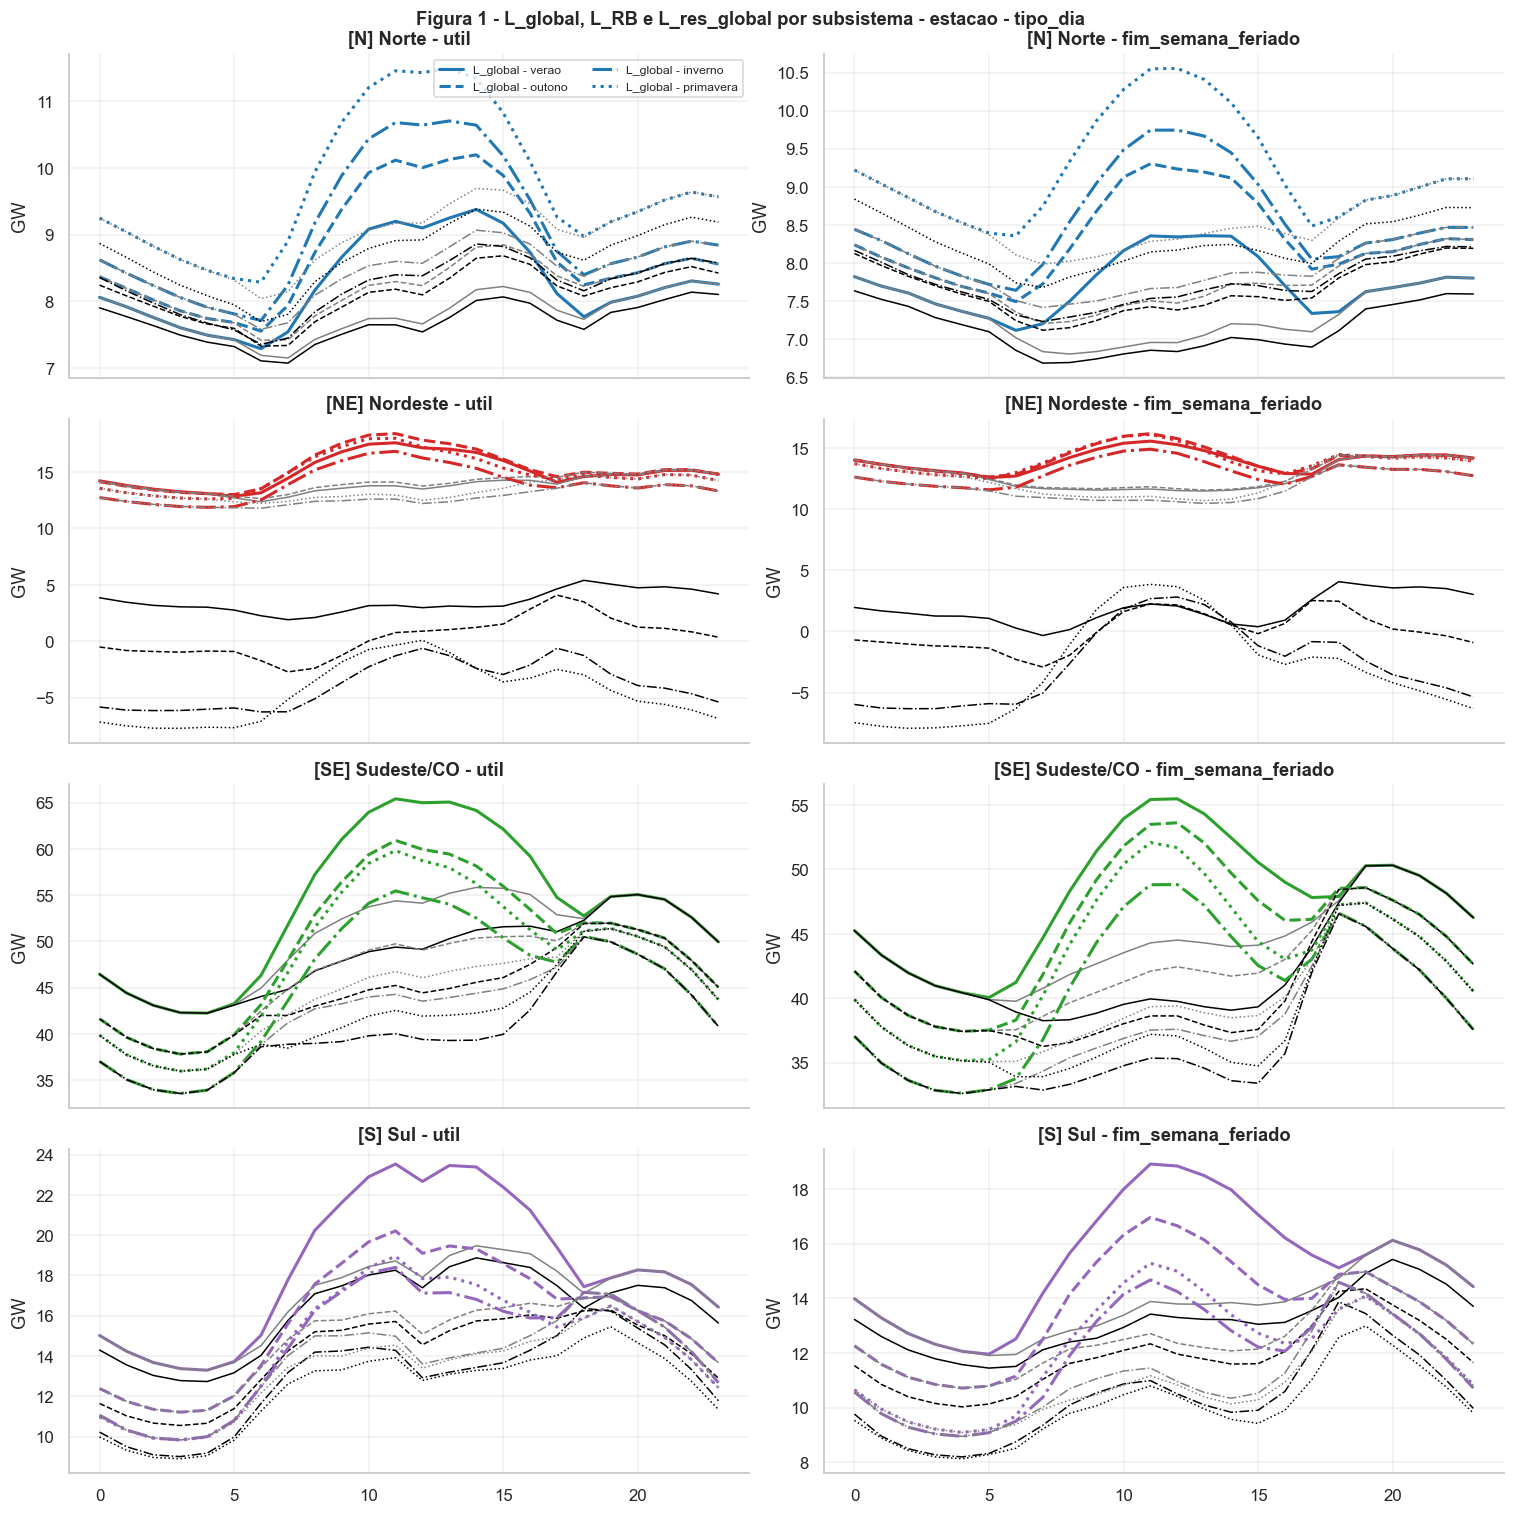

In [7]:
def avg_profile(df, cols, by=("id_subsistema", "estacao", "tipo_dia_g", "hora")):
    return df.groupby(list(by), observed=False)[list(cols)].mean().reset_index()

PROFILE_COLS = ["L_global", "L_RB", "L_net_s_grid", "L_net_s_global", "L_res_grid", "L_res_global", "G_s_centralizada", "G_s_MMGD", "G_s_all", "G_w_total", "G_h_total"]
prof = avg_profile(panel, PROFILE_COLS)
prof.to_csv(TABLE_DIR / "tab_perfis_horarios_carga.csv", index=False, float_format="%.1f")

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=True)
for j, td in enumerate(["util", "fim_semana_feriado"]):
    for i, sub in enumerate(SUBSYS_ORDER):
        ax = axes[i, j]
        for est, ls in zip(SEASON_ORDER, ["-", "--", "-.", ":"]):
            g = prof.query("id_subsistema == @sub and estacao == @est and tipo_dia_g == @td")
            if len(g) == 0:
                continue
            ax.plot(g["hora"], g["L_global"]/1000, color=SUB_COLOR[sub], ls=ls, lw=2, label=f"L_global - {est}")
            ax.plot(g["hora"], g["L_RB"]/1000, color="gray", ls=ls, lw=1)
            ax.plot(g["hora"], g[L_RES_DEFAULT]/1000, color="black", ls=ls, lw=1)
        ax.set_title(f"[{sub}] {SUB_LABEL[sub]} - {td}")
        ax.set_ylabel("GW")
        ax.grid(alpha=.3)
axes[0, 0].legend(fontsize=8, ncols=2, loc="upper right")
fig.suptitle(f"Figura 1 - L_global, L_RB e {L_RES_DEFAULT} por subsistema - estacao - tipo_dia", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig01_carga_global_rb_res.png", bbox_inches="tight")
plt.show()


## 7. Diagnóstico operacional — Figura 2

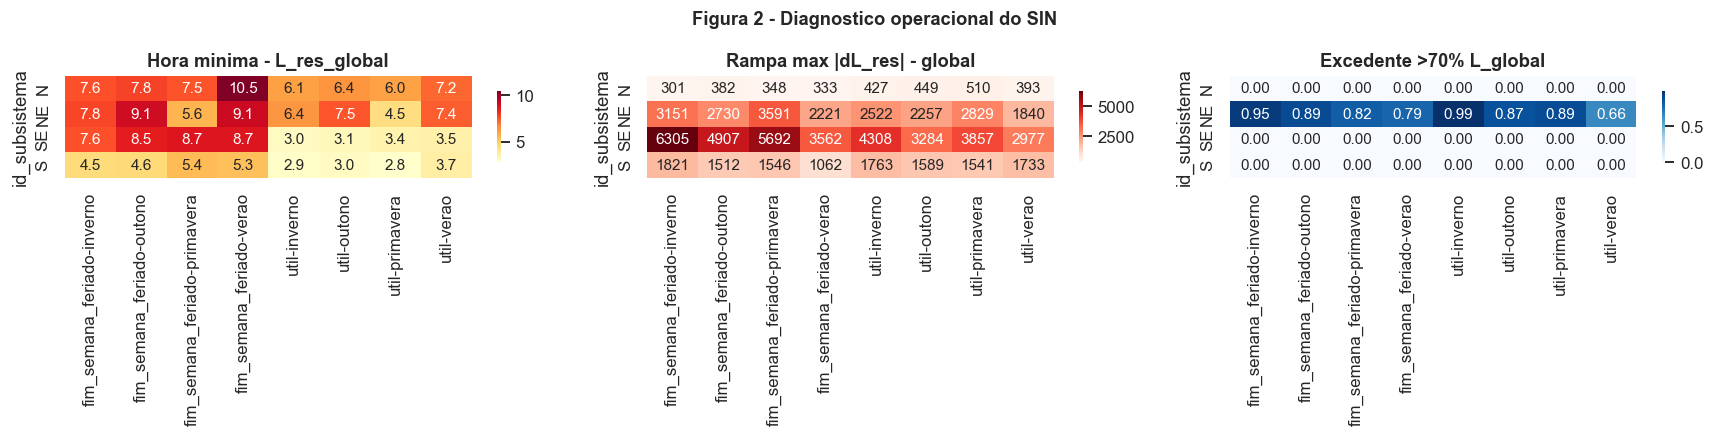

id_subsistema   estacao           tipo_dia load_family L_net_metric L_res_metric  hora_min_L_res  rampa_max_dL_net_s  rampa_max_dL_res
            N   inverno fim_semana_feriado        grid L_net_s_grid   L_res_grid            7.57              294.80            300.98
            N   inverno               util        grid L_net_s_grid   L_res_grid            6.09              437.51            426.86
            N    outono fim_semana_feriado        grid L_net_s_grid   L_res_grid            7.81              355.64            382.24
            N    outono               util        grid L_net_s_grid   L_res_grid            6.42              439.48            448.54
            N primavera fim_semana_feriado        grid L_net_s_grid   L_res_grid            7.50              336.95            347.88
            N primavera               util        grid L_net_s_grid   L_res_grid            6.05              498.47            509.84
            N     verao fim_semana_feriado        grid 

In [8]:
GROUP_KEYS = ["id_subsistema", "estacao", "tipo_dia_g", "data"]
ag = panel.groupby(GROUP_KEYS, observed=False)

ramp_tables = []
for family, net_col, res_col, dnet_col, dres_col in [
    ("grid", "L_net_s_grid", "L_res_grid", "dL_net_s_grid", "dL_res_grid"),
    ("global", "L_net_s_global", "L_res_global", "dL_net_s_global", "dL_res_global"),
]:
    hora_min = ag.apply(lambda x, c=res_col: x.loc[x[c].idxmin(), "hora"] if x[c].notna().any() else np.nan, include_groups=False).reset_index(name="hora_min_L_res")
    ramp_net = ag[dnet_col].apply(lambda x: x.abs().max()).reset_index(name="rampa_max_dL_net_s")
    ramp_res = ag[dres_col].apply(lambda x: x.abs().max()).reset_index(name="rampa_max_dL_res")
    tab = hora_min.merge(ramp_net, on=GROUP_KEYS, how="left").merge(ramp_res, on=GROUP_KEYS, how="left")
    tab_avg = (tab.groupby(["id_subsistema", "estacao", "tipo_dia_g"], observed=False)[["hora_min_L_res", "rampa_max_dL_net_s", "rampa_max_dL_res"]].mean().reset_index())
    tab_avg["load_family"] = family
    tab_avg["L_net_metric"] = net_col
    tab_avg["L_res_metric"] = res_col
    ramp_tables.append(tab_avg.rename(columns={"tipo_dia_g": "tipo_dia"}))

tab_ramps = pd.concat(ramp_tables, ignore_index=True)
tab_ramps = tab_ramps[["id_subsistema", "estacao", "tipo_dia", "load_family", "L_net_metric", "L_res_metric", "hora_min_L_res", "rampa_max_dL_net_s", "rampa_max_dL_res"]]
tab_ramps.to_csv(TABLE_DIR / "tab_ramps_by_subsystem_season_daytype.csv", index=False, float_format="%.3f")

ramp_default = tab_ramps.query("load_family == @DEFAULT_SCOPE").copy()
d = panel.copy()
d["pot_exc"] = ((d[DEFAULT_SOLAR_COL] + d["G_w_total"]) > 0.7 * d[DEFAULT_LOAD_COL]).astype(int)
exc = d.groupby(["id_subsistema", "estacao", "tipo_dia_g"], observed=False)["pot_exc"].mean().reset_index().rename(columns={"tipo_dia_g": "tipo_dia"})

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
def heatmap(df, val, title, ax, fmt=".1f", cmap="viridis"):
    piv = df.pivot_table(index="id_subsistema", columns=["tipo_dia", "estacao"], values=val).reindex(index=SUBSYS_ORDER)
    sns.heatmap(piv, annot=True, fmt=fmt, cmap=cmap, ax=ax, cbar_kws={"shrink": .7})
    ax.set_title(title); ax.set_xlabel("")
heatmap(ramp_default, "hora_min_L_res", f"Hora minima - {L_RES_DEFAULT}", axes[0], fmt=".1f", cmap="YlOrRd")
heatmap(ramp_default, "rampa_max_dL_res", f"Rampa max |dL_res| - {DEFAULT_SCOPE}", axes[1], fmt=".0f", cmap="Reds")
heatmap(exc, "pot_exc", f"Excedente >70% {DEFAULT_LOAD_COL}", axes[2], fmt=".2f", cmap="Blues")
fig.suptitle("Figura 2 - Diagnostico operacional do SIN", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig02_diagnostico_operacional.png", bbox_inches="tight")
plt.show()
print(tab_ramps.head(12).round(2).to_string(index=False))


## 8. Curva do pato contrafactual — Figura 4

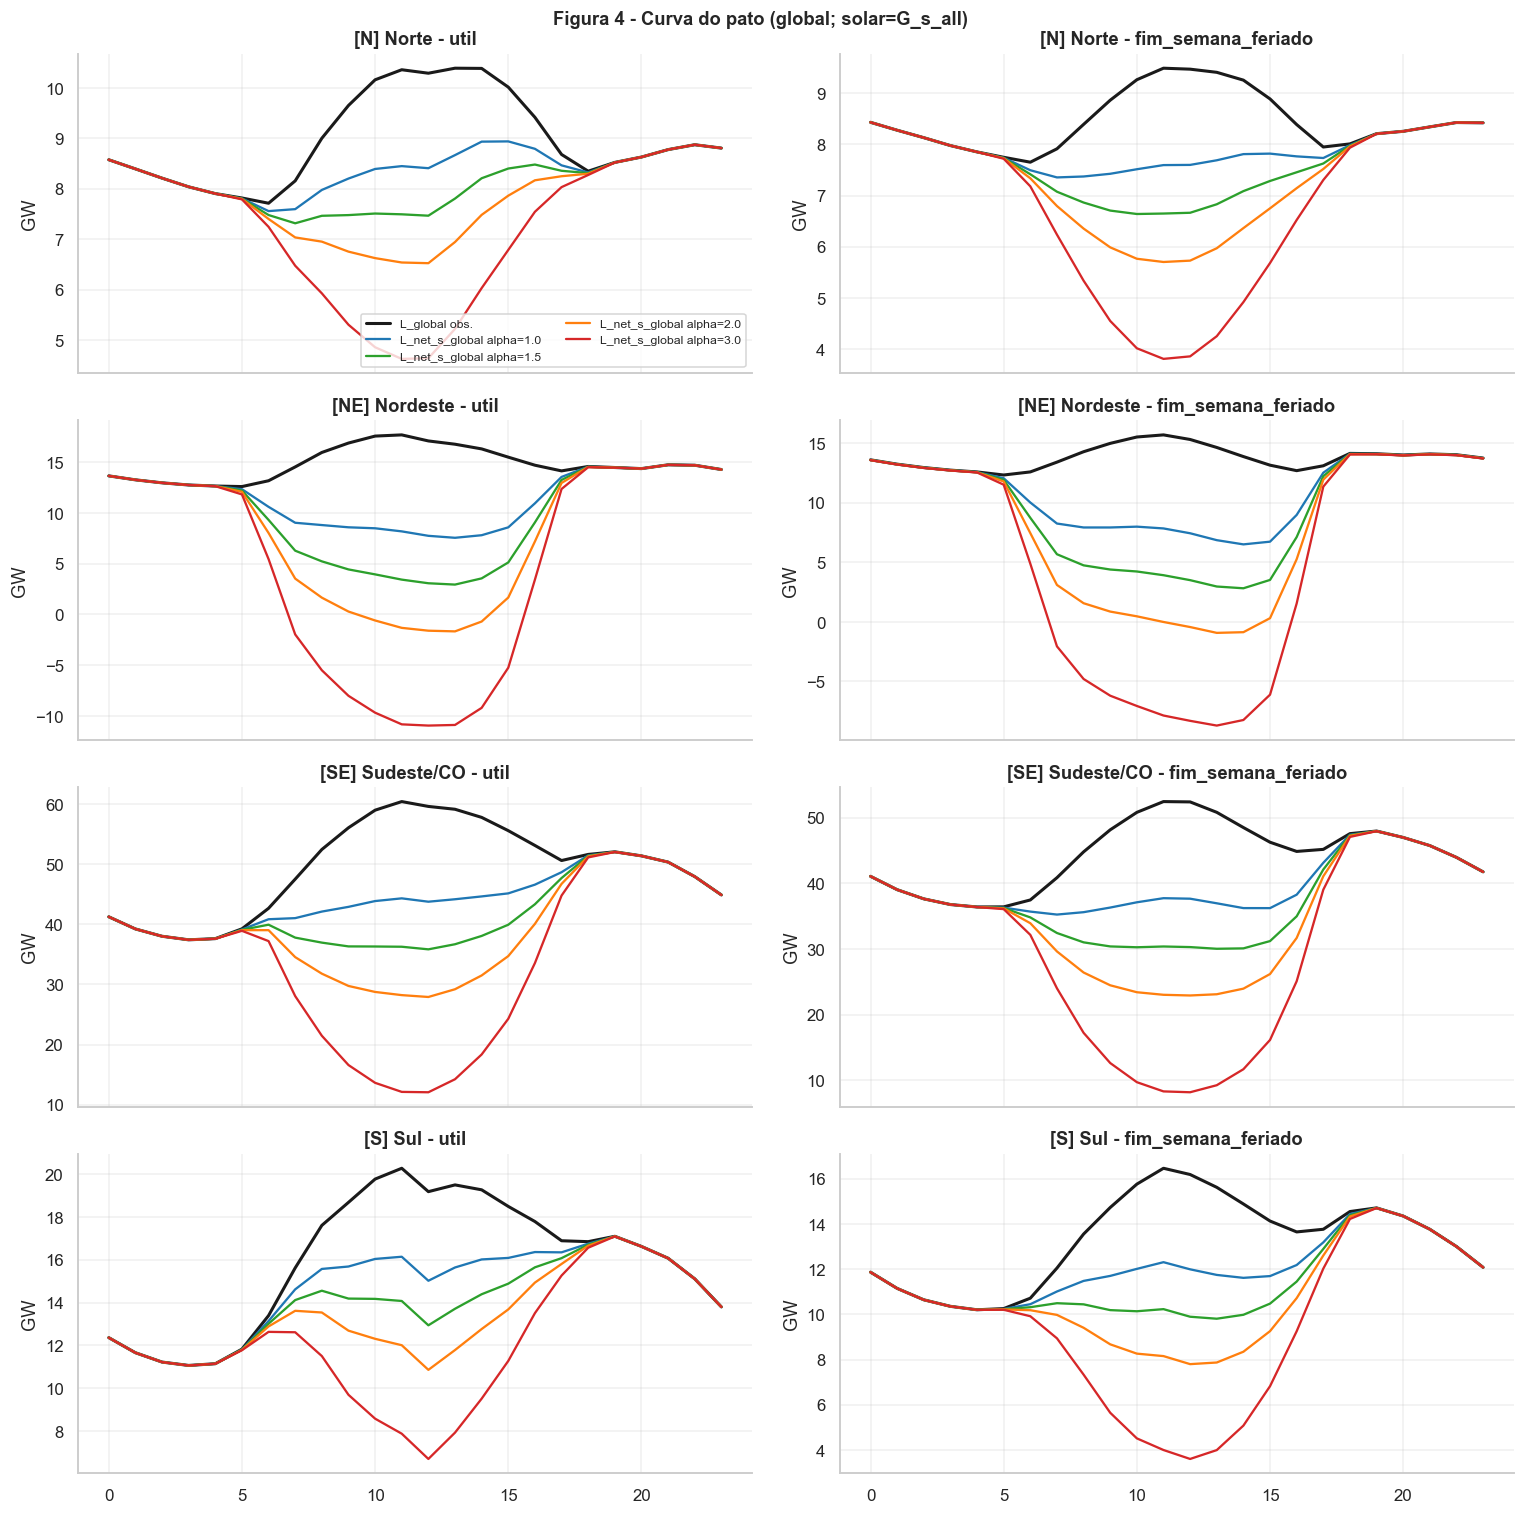

In [9]:
ALPHAS = [1.0, 1.5, 2.0, 3.0]
typ = panel.groupby(["id_subsistema", "estacao", "tipo_dia_g", "hora"], observed=False).agg(
    L_default=(DEFAULT_LOAD_COL, "mean"),
    G_s_default=(DEFAULT_SOLAR_COL, "mean"),
    G_w_total=("G_w_total", "mean"),
    G_h_total=("G_h_total", "mean"),
).reset_index()

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=True)
for j, td in enumerate(["util", "fim_semana_feriado"]):
    for i, sub in enumerate(SUBSYS_ORDER):
        ax = axes[i, j]
        g = typ.query("id_subsistema == @sub and tipo_dia_g == @td")
        gp = g.groupby("hora").mean(numeric_only=True).reset_index()
        ax.plot(gp["hora"], gp["L_default"]/1000, "k-", lw=2, label=f"{DEFAULT_LOAD_COL} obs.")
        for alpha, col in zip(ALPHAS, ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]):
            Ln = gp["L_default"] - alpha * gp["G_s_default"]
            ax.plot(gp["hora"], Ln/1000, color=col, lw=1.5, label=f"{L_NET_DEFAULT} alpha={alpha}")
        ax.set_title(f"[{sub}] {SUB_LABEL[sub]} - {td}")
        ax.set_ylabel("GW"); ax.grid(alpha=.3)
axes[0, 0].legend(fontsize=8, ncols=2)
fig.suptitle(f"Figura 4 - Curva do pato ({DEFAULT_SCOPE}; solar={DEFAULT_SOLAR_COL})", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig04_curva_pato_contrafactual.png", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig_duck_curve_by_subsystem_season_daytype.png", bbox_inches="tight")
plt.show()


## 9. Precos: `CMO_obs`, `PLD_obs`, `PLD_hat`, `lambda_model`

Quatro entidades **distintas**. `PLD_hat` - clip do CMO; `PLD_obs` - mantido como campo separado, mas a serie oficial de PLD horario nao est- disponvel nesta base.

Como a serie oficial de PLD horario nao est- disponvel nesta base, usamos `PLD_hat` apenas como proxy construida a partir de `CMO_obs` e limites regulatorios. `PLD_hat` nao deve ser interpretado como PLD oficial.


In [10]:
PLD_MIN_2025 = 65.69
PLD_MAX_2025 = 939.96

panel = panel.merge(cmo[["din_instante", "id_subsistema", "cmo_h"]], on=["din_instante", "id_subsistema"], how="left")
panel = panel.rename(columns={"cmo_h": "CMO_obs"})
panel["PLD_obs"] = np.nan
panel["PLD_hat"] = panel["CMO_obs"].clip(lower=PLD_MIN_2025, upper=PLD_MAX_2025)

PLD_OBS_AVAILABLE = bool(panel["PLD_obs"].notna().any())
CAPTURE_PRICE_METRICS = [("CMO_obs", "F_capture_CMO")]
if PLD_OBS_AVAILABLE:
    CAPTURE_PRICE_METRICS.append(("PLD_obs", "F_capture_PLD_obs"))
CAPTURE_PRICE_METRICS.append(("PLD_hat", "F_capture_PLD_hat"))
CAPTURE_PRICE_COLS = [m[0] for m in CAPTURE_PRICE_METRICS]

if not PLD_OBS_AVAILABLE:
    print("PLD_obs indisponivel: graficos/tabelas finais de captura usam CMO_obs e PLD_hat.")
print(panel.groupby("id_subsistema")[["CMO_obs", "PLD_hat"]].describe().round(1).to_string())


PLD_obs indisponivel: graficos/tabelas finais de captura usam CMO_obs e PLD_hat.
              CMO_obs                                                PLD_hat                                               
                count   mean    std  min   25%    50%    75%     max   count   mean    std   min   25%    50%    75%    max
id_subsistema                                                                                                              
N              7272.0  139.8  137.2 -0.1  12.7   56.9  281.9   668.1  7272.0  166.2  112.9  65.7  65.7   65.7  281.9  668.1
NE             7272.0  127.0  134.0 -4.1   1.3   42.2  268.7   668.0  7272.0  156.5  108.0  65.7  65.7   65.7  268.7  668.0
S              7272.0  215.0  132.3 -0.1  96.0  262.6  316.7  1653.2  7272.0  226.2  113.6  65.7  96.0  262.6  316.7  940.0
SE             7272.0  202.7  134.0 -0.0  58.6  251.3  310.0  1652.1  7272.0  215.3  114.4  65.7  65.7  251.3  310.0  940.0


## 10. Fator de captura agregado por metrica (`CMO_obs`, `PLD_hat`)

`PLD_obs` s- entra se houver observacoes nao nulas. Nesta base, como a serie oficial horaria est- vazia, os graficos finais usam apenas `F_capture_CMO` e `F_capture_PLD_hat`.


tag                  F_capture_CMO  F_capture_PLD_hat
id_subsistema fonte                                  
N             solar          0.671              0.783
              wind           1.356              1.245
NE            solar          0.575              0.727
              wind           1.220              1.146
S             solar          0.703              0.772
              wind           1.065              1.052
SE            solar          0.706              0.775
              wind           1.011              0.998


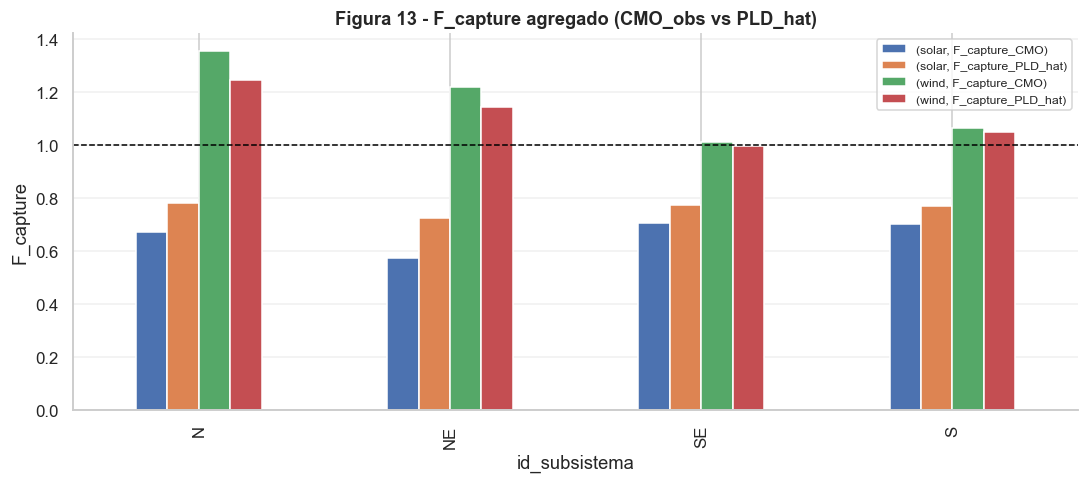

In [11]:
def f_capture(df, sub, gen_col, price_col):
    g = df[(df["id_subsistema"] == sub)].dropna(subset=[price_col, gen_col])
    if len(g) == 0 or g[gen_col].sum() <= 0:
        return np.nan, np.nan, np.nan
    P_avg = float(g[price_col].mean())
    P_cap = float((g[price_col] * g[gen_col]).sum() / g[gen_col].sum())
    return (P_cap / P_avg if P_avg > 0 else np.nan), P_avg, P_cap

records = []
for sub in SUBSYS_ORDER:
    for src, gcol in [("solar", DEFAULT_SOLAR_COL), ("wind", "G_w_total")]:
        for price_col, tag in CAPTURE_PRICE_METRICS:
            Fc, Pavg, Pcap = f_capture(panel, sub, gcol, price_col)
            records.append({"id_subsistema": sub, "fonte": src, "generation_metric": gcol, "tag": tag, "F_capture": Fc, "P_avg": Pavg, "P_cap": Pcap})
fcap = pd.DataFrame(records)
fcap.to_csv(TABLE_DIR / "tab_fator_captura.csv", index=False, float_format="%.4f")
piv = fcap.pivot_table(index=["id_subsistema", "fonte"], columns="tag", values="F_capture")
print(piv.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 4.5))
df_plot = (fcap.query("tag in ['F_capture_CMO', 'F_capture_PLD_hat']").pivot_table(index="id_subsistema", columns=["fonte", "tag"], values="F_capture").reindex(SUBSYS_ORDER))
df_plot.plot.bar(ax=ax)
ax.axhline(1.0, color="black", ls="--", lw=1)
ax.set_title("Figura 13 - F_capture agregado (CMO_obs vs PLD_hat)")
ax.set_ylabel("F_capture"); ax.legend(fontsize=8); ax.grid(alpha=.3, axis="y")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig13_fator_captura.png", bbox_inches="tight")
plt.show()


## 11. Fator de captura por subsistema - fonte - estacao - tipo_dia - metrica

Define claramente:

- Fonte: `solar` usa a metrica solar default (`G_s_all` nesta v4 global); `wind` usa `G_w_total`.
- Mtrica de preco: `CMO_obs` e `PLD_hat`; `PLD_obs` s- entra se existir serie oficial nao nula.
- No mistura `CMO_obs`, `PLD_hat`, `PLD_obs` e `lambda_model`.


id_subsistema fonte generation_metric   estacao tipo_dia price_metric  P_avg_metric  P_capture_source  F_capture
            N solar           G_s_all   inverno  domingo      CMO_obs       164.727            21.591      0.131
            N solar           G_s_all   inverno  feriado      CMO_obs       184.305            36.009      0.195
            N solar           G_s_all   inverno   sabado      CMO_obs       192.586            52.561      0.273
            N solar           G_s_all   inverno     util      CMO_obs       250.368           187.742      0.750
            N solar           G_s_all    outono  domingo      CMO_obs        28.741             2.170      0.075
            N solar           G_s_all    outono  feriado      CMO_obs        30.894             4.043      0.131
            N solar           G_s_all    outono   sabado      CMO_obs        49.204            12.534      0.255
            N solar           G_s_all    outono     util      CMO_obs        68.811            5

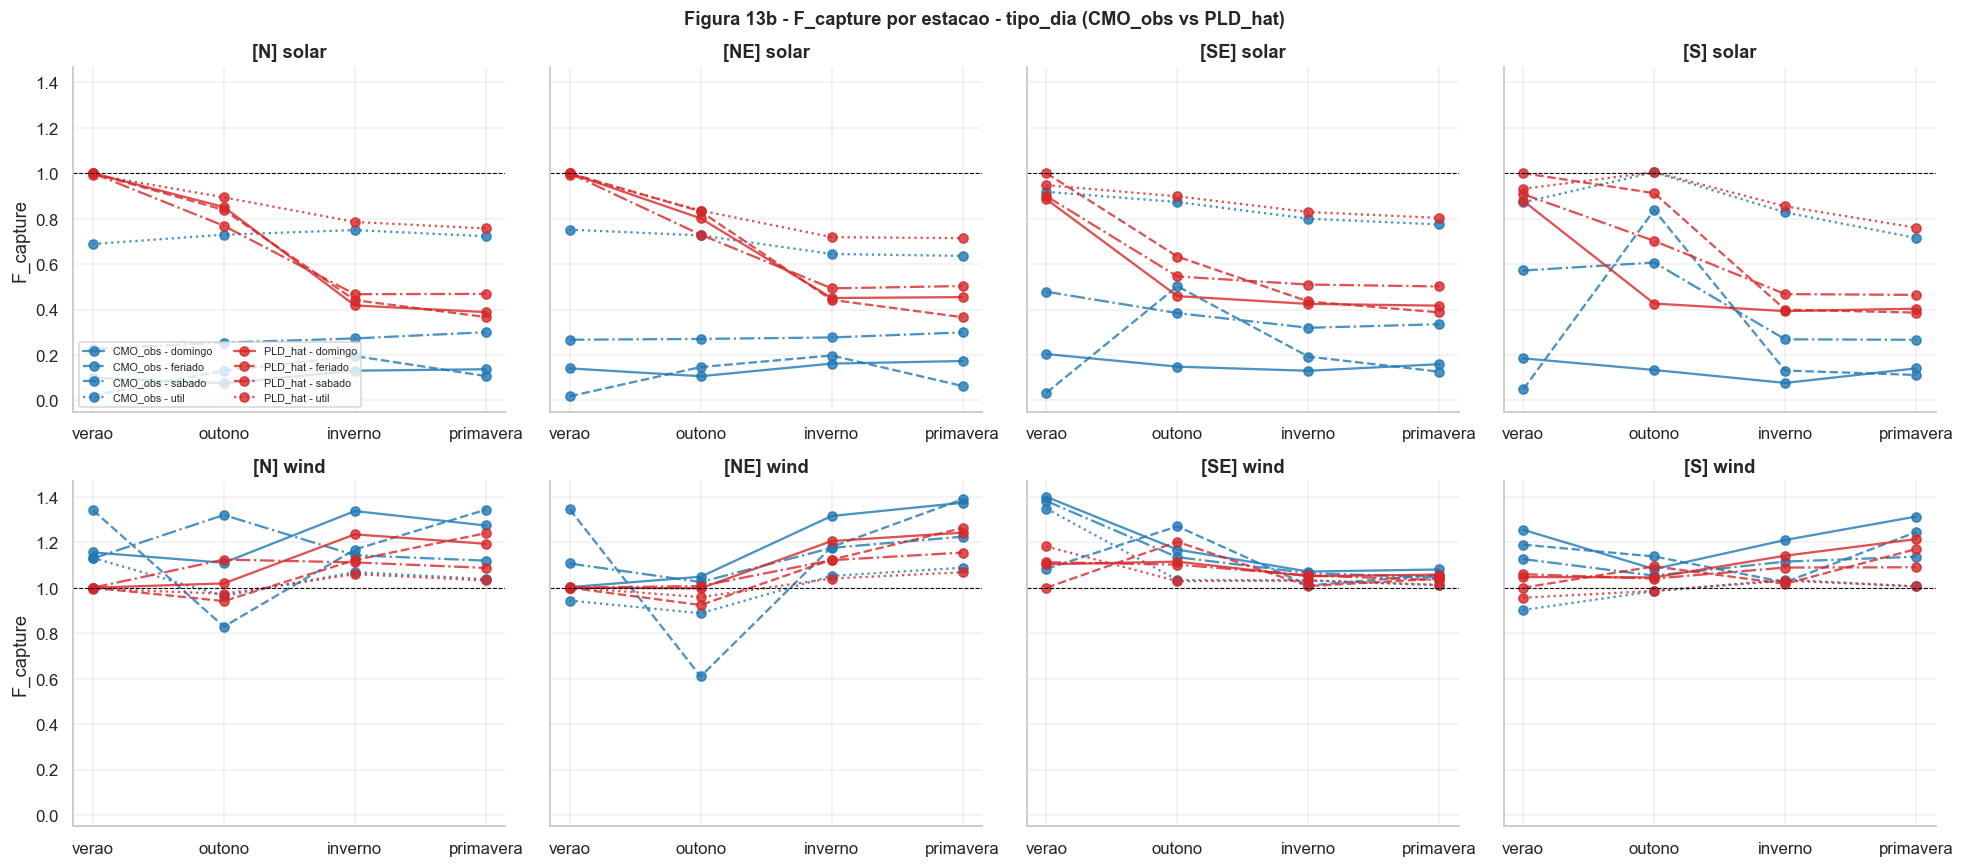

In [12]:
def f_capture_grouped(df, gen_col, price_col, by=("id_subsistema", "estacao", "tipo_dia")):
    rows = []
    for keys, g in df.groupby(list(by), observed=False):
        gd = g.dropna(subset=[price_col, gen_col])
        if len(gd) == 0 or gd[gen_col].sum() <= 0:
            P_avg = P_cap = Fc = np.nan
        else:
            P_avg = float(gd[price_col].mean())
            P_cap = float((gd[price_col] * gd[gen_col]).sum() / gd[gen_col].sum())
            Fc = P_cap / P_avg if P_avg > 0 else np.nan
        row = dict(zip(by, keys if isinstance(keys, tuple) else (keys,)))
        row.update({"price_metric": price_col, "P_avg_metric": P_avg, "P_capture_source": P_cap, "F_capture": Fc})
        rows.append(row)
    return rows

all_rows = []
for src, gcol in [("solar", DEFAULT_SOLAR_COL), ("wind", "G_w_total")]:
    for price_col in CAPTURE_PRICE_COLS:
        rs = f_capture_grouped(panel, gcol, price_col)
        for r in rs:
            r["fonte"] = src
            r["generation_metric"] = gcol
            all_rows.append(r)
fcap_season = pd.DataFrame(all_rows)
fcap_season = fcap_season[["id_subsistema", "fonte", "generation_metric", "estacao", "tipo_dia", "price_metric", "P_avg_metric", "P_capture_source", "F_capture"]]
fcap_season.to_csv(TABLE_DIR / "tab_capture_factors_by_season_daytype.csv", index=False, float_format="%.4f")
print(fcap_season.dropna().query("price_metric == 'CMO_obs'").head(12).round(3).to_string(index=False))

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=True)
metric_colors = {"CMO_obs": "#1f77b4", "PLD_hat": "#d62728", "PLD_obs": "#9467bd"}
for row, src in enumerate(["solar", "wind"]):
    for col, sub in enumerate(SUBSYS_ORDER):
        ax = axes[row, col]
        for metric in [m for m in ["CMO_obs", "PLD_hat"] if m in CAPTURE_PRICE_COLS]:
            d = fcap_season.query("fonte == @src and id_subsistema == @sub and price_metric == @metric")
            piv = d.pivot_table(index="estacao", columns="tipo_dia", values="F_capture").reindex(SEASON_ORDER)
            for td_col, ls in zip(piv.columns, ["-", "--", "-.", ":"]):
                ax.plot(piv.index, piv[td_col], "o-", color=metric_colors[metric], ls=ls, lw=1.5, label=f"{metric} - {td_col}", alpha=.8)
        ax.set_title(f"[{sub}] {src}")
        ax.axhline(1.0, color="black", ls="--", lw=.7)
        ax.grid(alpha=.3)
        if col == 0:
            ax.set_ylabel("F_capture")
axes[0, 0].legend(fontsize=7, loc="lower left", ncols=2)
fig.suptitle("Figura 13b - F_capture por estacao - tipo_dia (CMO_obs vs PLD_hat)", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_capture_factors_by_season_daytype.png", bbox_inches="tight")
plt.show()


## 12. Hidrologia (PROXY)

Sem cota montante/jusante e vazão turbinada por usina, todos os blocos
hidrológicos usam **proxies**: afluência observada (`A_MW`), geração observada
(`G_h_total`) e `vol_util_pct`. Fórmula física $P_h = \eta \cdot \rho \cdot g \cdot h_{liq} \cdot q_{turb}$
fica apenas como referência.

**Usar cota jusante dos dados, usamos proxy visto falta de confiabilidade** TODO

`S_t` no despacho é uma **proxy de energia armazenada em MWh-equivalente**
(não volume físico), construída via `vol_util_pct` mapeado para uma escala
calibrada pela faixa de afluência observada.


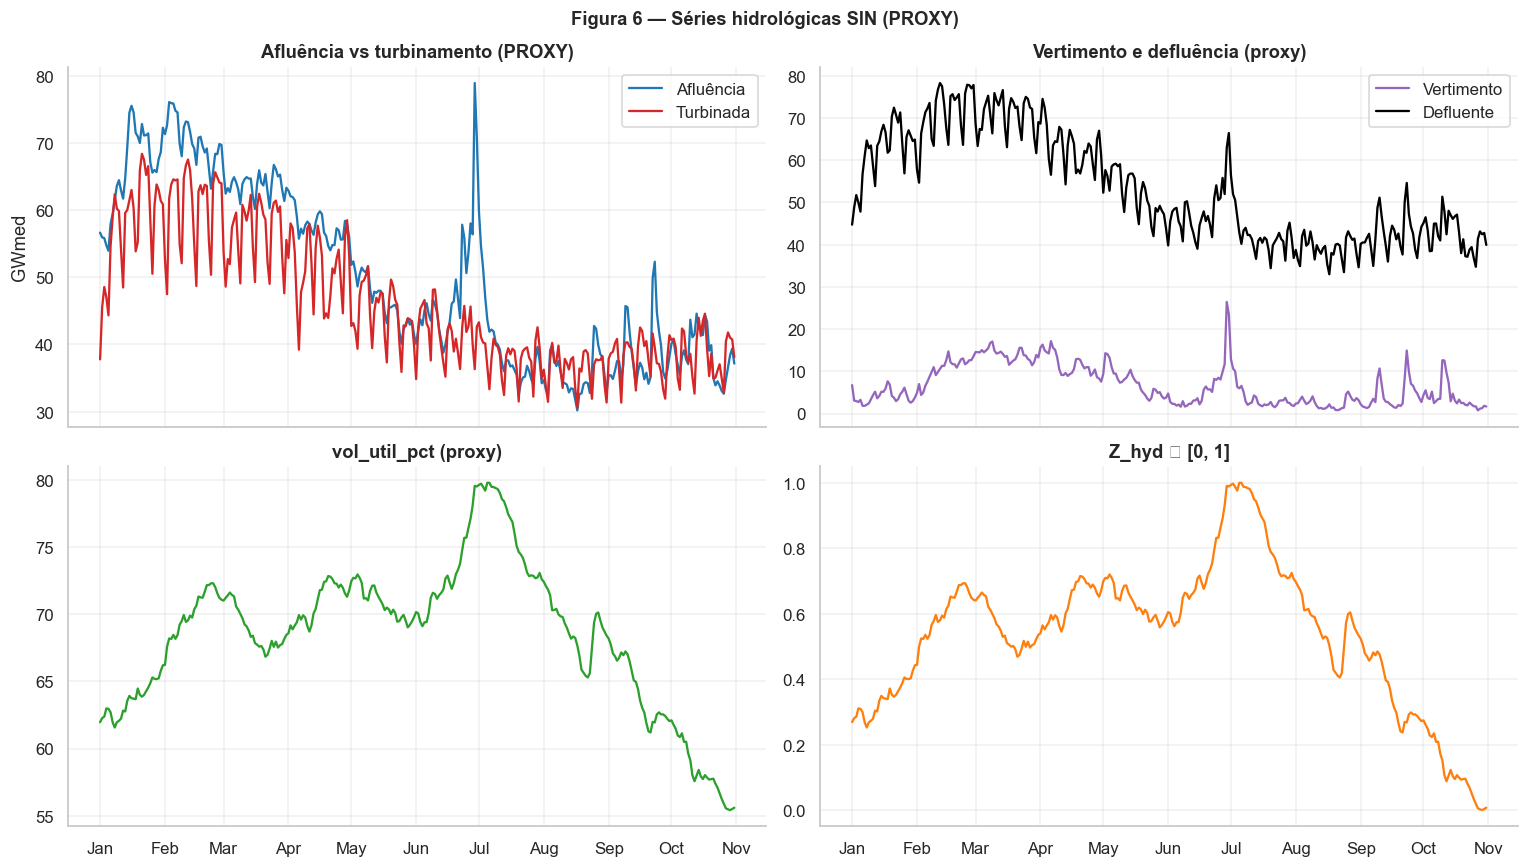

In [13]:
hydro_sin = hydro.copy()
hydro_sin["Storage_MW"] = hydro_sin["A_MW"].cumsum() - hydro_sin["Outflow_MW"].cumsum()
if hydro_sin["vol_util_pct"].notna().any():
    s = hydro_sin["vol_util_pct"]
else:
    s = hydro_sin["Storage_MW"]
hydro_sin["Z_hyd"] = (s - s.min()) / max(s.max() - s.min(), 1e-9)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes[0, 0].plot(hydro_sin["din_instante"], hydro_sin["A_MW"]/1000, label="Afluência", color="#1f77b4")
axes[0, 0].plot(hydro_sin["din_instante"], hydro_sin["T_MW"]/1000, label="Turbinada", color="#d62728")
axes[0, 0].set_title("Afluência vs turbinamento (PROXY)"); axes[0, 0].set_ylabel("GWmed")
axes[0, 0].legend(); axes[0, 0].grid(alpha=.3)
axes[0, 1].plot(hydro_sin["din_instante"], hydro_sin["Spill_MW"]/1000, label="Vertimento", color="#9467bd")
axes[0, 1].plot(hydro_sin["din_instante"], hydro_sin["Outflow_MW"]/1000, label="Defluente", color="black")
axes[0, 1].set_title("Vertimento e defluência (proxy)"); axes[0, 1].legend(); axes[0, 1].grid(alpha=.3)
axes[1, 0].plot(hydro_sin["din_instante"], hydro_sin["vol_util_pct"], color="#2ca02c")
axes[1, 0].set_title("vol_util_pct (proxy)"); axes[1, 0].grid(alpha=.3)
axes[1, 1].plot(hydro_sin["din_instante"], hydro_sin["Z_hyd"], color="#ff7f0e")
axes[1, 1].set_title("Z_hyd ∈ [0, 1]"); axes[1, 1].grid(alpha=.3)
for ax in axes.flat:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
fig.suptitle("Figura 6 — Séries hidrológicas SIN (PROXY)", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig06_hidrologia_proxy.png", bbox_inches="tight")
plt.show()


## 13. Calibração de parâmetros do despacho

`CMO_obs = c1 + c2 · G_th_total` (térmica **despachável** somente; nuclear não
entra). `K_th_eff_p99` é a capacidade térmica efetiva. Rampa via p99 de `|ΔG_th|`.

`E_hydro_budget` (orçamento diário de energia hidráulica) calibrado para 95%
da geração hidro observada no dia típico, evitando engessamento.


In [ ]:
g = panel.dropna(subset=["CMO_obs"]).copy()
y = g["CMO_obs"].values
x = g["G_th_total"].values
A = np.column_stack([np.ones_like(x), x])
coef, *_ = np.linalg.lstsq(A, y, rcond=None)
c1_calib = max(float(coef[0]), 50.0)
c2_calib = max(float(coef[1]), 1e-5)

agg_panel = panel.groupby("din_instante", as_index=False).agg(
    L_dispatch=(DEFAULT_LOAD_COL, "sum"),
    G_s_dispatch=(DEFAULT_SOLAR_COL, "sum"),
    G_w_total=("G_w_total", "sum"),
    G_h_total=("G_h_total", "sum"),
    G_th_total=("G_th_total", "sum"),
    G_nuc_inflex=("G_nuc_inflex", "sum"),
)
K_TH_SIN  = float(np.nanquantile(agg_panel["G_th_total"], 0.995))
K_H_SIN   = float(np.nanquantile(agg_panel["G_h_total"],  0.995))
K_NUC_SIN = float(np.nanquantile(agg_panel["G_nuc_inflex"], 0.995))
dG_th = agg_panel["G_th_total"].diff().abs().dropna()
rho_up = rho_dn = float(np.nanquantile(dG_th, 0.99))

PARAMS = {
    "c1_RS_per_MWh": round(c1_calib, 2),
    "c2_RS_per_MWh2": round(c2_calib, 6),
    "K_TH_SIN_MW": round(K_TH_SIN, 0),
    "K_H_SIN_MW": round(K_H_SIN, 0),
    "K_NUC_SIN_MW": round(K_NUC_SIN, 0),
    "rho_up_MW_per_h": round(rho_up, 0),
    "rho_dn_MW_per_h": round(rho_dn, 0),
    "pi_curt_RS_per_MWh": 30.0,
    "pi_def_RS_per_MWh": 3500.0,
    "VOLL_RS_per_MWh": 3500.0,
    "water_opportunity_cost": 80.0,
    "shadow_water_value_proxy": 60.0,
    "dispatch_load_metric": DEFAULT_LOAD_COL,
    "dispatch_solar_metric": DEFAULT_SOLAR_COL,
}
pd.DataFrame.from_dict(PARAMS, orient="index", columns=["valor"]).to_csv(TABLE_DIR / "tab_params_dispatch.csv")
print(pd.DataFrame.from_dict(PARAMS, orient="index", columns=["valor"]).to_string())


                             valor
c1_RS_per_MWh               123.48
c2_RS_per_MWh2            0.023424
K_TH_SIN_MW                13676.0
K_H_SIN_MW                 81102.0
K_NUC_SIN_MW                2016.0
rho_up_MW_per_h              683.0
rho_dn_MW_per_h              683.0
pi_curt_RS_per_MWh            30.0
pi_def_RS_per_MWh           3500.0
VOLL_RS_per_MWh             3500.0
water_opportunity_cost        80.0
shadow_water_value_proxy      60.0
dispatch_load_metric      L_global
dispatch_solar_metric      G_s_all


## 14. Despacho centralizado com **estado de reservatório `S_t`**

Modelo intra-diário com inflow proxy uniforme (afluência média do dia/24h),
estado `S_t` normalizado em MWh-equivalentes, vertimento `spill_t` e
penalidade `water_opportunity_cost` por uso da água.
Não chamamos de "valor terminal" rigoroso — é um *shadow_water_value_proxy*:
$\min (\text{custos}) - V_S \cdot S_T$.

Balanço com `L_t`:

$G_s + G_w + h + n + G_{nuc} = L + curt - def$

Dinâmica do reservatório:

$S_{t+1} = S_t + \text{inflow}_t - h_t - \text{spill}_t,\quad
S_{\min} \le S_t \le S_{\max},\quad
h_t, \text{spill}_t \ge 0.$

A nuclear `G_{nuc}` entra como **geração inflexível** (constante igual a
`K_NUC` quando o subsistema tem nuclear). Térmica `n_t` é despachável.


In [15]:
@dataclass
class ReservoirSpec:
    S_max: float
    S_min: float
    S_init: float
    inflow: np.ndarray


def solve_dispatch_with_reservoir(
    L: np.ndarray, G_s: np.ndarray, G_w: np.ndarray, G_nuc: np.ndarray,
    K_T: float, c1: float, c2: float, rho_up: float, rho_dn: float,
    reservoir: ReservoirSpec,
    K_H_inst: float | None = None,
    water_opportunity_cost: float = 80.0,
    shadow_water_value_proxy: float = 60.0,
    pi_curt: float = 30.0, pi_def: float = 3500.0,
) -> dict:
    """Despacho horario com estado de reservatorio e par L/G_s coerente com o default."""
    T = len(L)
    n = cp.Variable(T, nonneg=True)
    h = cp.Variable(T, nonneg=True)
    spill = cp.Variable(T, nonneg=True)
    curt = cp.Variable(T, nonneg=True)
    defc = cp.Variable(T, nonneg=True)
    S = cp.Variable(T + 1, nonneg=True)

    cost = (c1 * cp.sum(n) + 0.5 * c2 * cp.sum_squares(n)
            + pi_curt * cp.sum(curt) + pi_def * cp.sum(defc)
            + water_opportunity_cost * cp.sum(h)
            - shadow_water_value_proxy * S[T])
    bal = (G_s + G_w + G_nuc + h + n) - (L + curt - defc) == 0
    cons = [bal, n <= K_T, n[1:] - n[:-1] <= rho_up, n[:-1] - n[1:] <= rho_dn,
            S[0] == reservoir.S_init, S <= reservoir.S_max, S >= reservoir.S_min]
    if K_H_inst is not None:
        cons.append(h <= K_H_inst)
    for t in range(T):
        cons.append(S[t + 1] == S[t] + reservoir.inflow[t] - h[t] - spill[t])
    prob = cp.Problem(cp.Minimize(cost), cons)
    prob.solve(solver=cp.CLARABEL)
    lam = -bal.dual_value if bal.dual_value is not None else np.full(T, np.nan)
    return {"status": prob.status, "cost": float(prob.value), "n": np.asarray(n.value), "h": np.asarray(h.value),
            "spill": np.asarray(spill.value), "curt": np.asarray(curt.value), "deficit": np.asarray(defc.value),
            "S": np.asarray(S.value), "lambda_model": np.asarray(lam)}


def typical_day(panel, sub, season, td) -> pd.DataFrame:
    g = panel.query("id_subsistema == @sub and estacao == @season and tipo_dia_g == @td")
    return g.groupby("hora").agg(
        L_global=("L_global", "mean"), L_RB=("L_RB", "mean"),
        L_net_s_grid=("L_net_s_grid", "mean"), L_res_grid=("L_res_grid", "mean"),
        L_net_s_global=("L_net_s_global", "mean"), L_res_global=("L_res_global", "mean"),
        G_s_centralizada=("G_s_centralizada", "mean"), G_s_MMGD=("G_s_MMGD", "mean"), G_s_all=("G_s_all", "mean"),
        G_w_total=("G_w_total", "mean"), G_h_total=("G_h_total", "mean"), G_th_total=("G_th_total", "mean"),
        G_nuc_inflex=("G_nuc_inflex", "mean"), CMO_obs=("CMO_obs", "mean"),
    ).reindex(range(24))

A_daily_avg = float(hydro_sin["A_MW"].mean())
inflow_per_sub_h = A_daily_avg / len(SUBSYS_ORDER)

rows = []
results_disp = {}
for sub in SUBSYS_ORDER:
    for est in SEASON_ORDER:
        for td in ["util", "fim_semana_feriado"]:
            prof = typical_day(panel, sub, est, td)
            if prof[DEFAULT_LOAD_COL].isna().all():
                continue
            prof = prof.ffill().bfill().fillna(0.0)
            L_t = prof[DEFAULT_LOAD_COL].values
            G_s_t = prof[DEFAULT_SOLAR_COL].values
            G_w_t = prof["G_w_total"].values
            G_nuc_t = prof["G_nuc_inflex"].values
            K_T_l = float(K_eff.loc[sub, "K_th_eff_p99"])
            K_H_l = float(K_eff.loc[sub, "K_h_eff_p99"])
            scale_sub = {"N": 0.8, "NE": 0.6, "SE": 1.0, "S": 0.4}[sub]
            reservoir = ReservoirSpec(S_max=24 * K_H_l * 5.0 * scale_sub, S_min=0.0,
                                      S_init=0.5 * 24 * K_H_l * 5.0 * scale_sub,
                                      inflow=np.full(24, inflow_per_sub_h * scale_sub))
            d_th = panel.loc[panel["id_subsistema"] == sub, "G_th_total"].diff().abs()
            rho_l = float(np.nanquantile(d_th.dropna(), 0.99))
            res = solve_dispatch_with_reservoir(
                L_t, G_s_t, G_w_t, G_nuc_t, K_T=K_T_l,
                c1=PARAMS["c1_RS_per_MWh"], c2=PARAMS["c2_RS_per_MWh2"], rho_up=rho_l, rho_dn=rho_l,
                reservoir=reservoir, K_H_inst=K_H_l,
                water_opportunity_cost=PARAMS["water_opportunity_cost"], shadow_water_value_proxy=PARAMS["shadow_water_value_proxy"],
                pi_curt=PARAMS["pi_curt_RS_per_MWh"], pi_def=PARAMS["pi_def_RS_per_MWh"])
            results_disp[(sub, est, td)] = res
            rows.append({"subsistema": sub, "estacao": est, "tipo_dia": td, "load_metric": DEFAULT_LOAD_COL, "solar_metric": DEFAULT_SOLAR_COL,
                         "status": res["status"], "cost": res["cost"], "G_th_dispatched": float(res["n"].sum()),
                         "G_h_used": float(res["h"].sum()), "spill_total": float(res["spill"].sum()), "S_T_residual": float(res["S"][-1]),
                         "curt_total": float(res["curt"].sum()), "deficit_total": float(res["deficit"].sum()),
                         "lambda_model_mean": float(np.nanmean(res["lambda_model"])), "CMO_obs_mean": float(np.nanmean(prof["CMO_obs"]))})
disp_summary = pd.DataFrame(rows)
disp_summary.to_csv(TABLE_DIR / "tab_despacho_centralizado.csv", index=False, float_format="%.2f")
print(disp_summary.round(1).to_string(index=False))


subsistema   estacao           tipo_dia load_metric solar_metric             status        cost  G_th_dispatched  G_h_used  spill_total  S_T_residual  curt_total  deficit_total  lambda_model_mean  CMO_obs_mean
         N     verao               util    L_global      G_s_all            optimal -42948342.4          16926.2  167625.0          0.0      976470.2         0.0            0.0              140.0          19.4
         N     verao fim_semana_feriado    L_global      G_s_all            optimal -44834746.3          16926.2  154150.7          0.0      989944.5         0.0            0.0              140.0          13.0
         N    outono               util    L_global      G_s_all            optimal -41567506.1          16926.2  177488.2          0.0      966607.0         0.0            0.0              140.0          68.8
         N    outono fim_semana_feriado    L_global      G_s_all            optimal -43083087.1          16926.2  166662.6          0.0      977432.6         0.

### Figura 7 — Despacho com reservatório (SE, verão, dia útil)

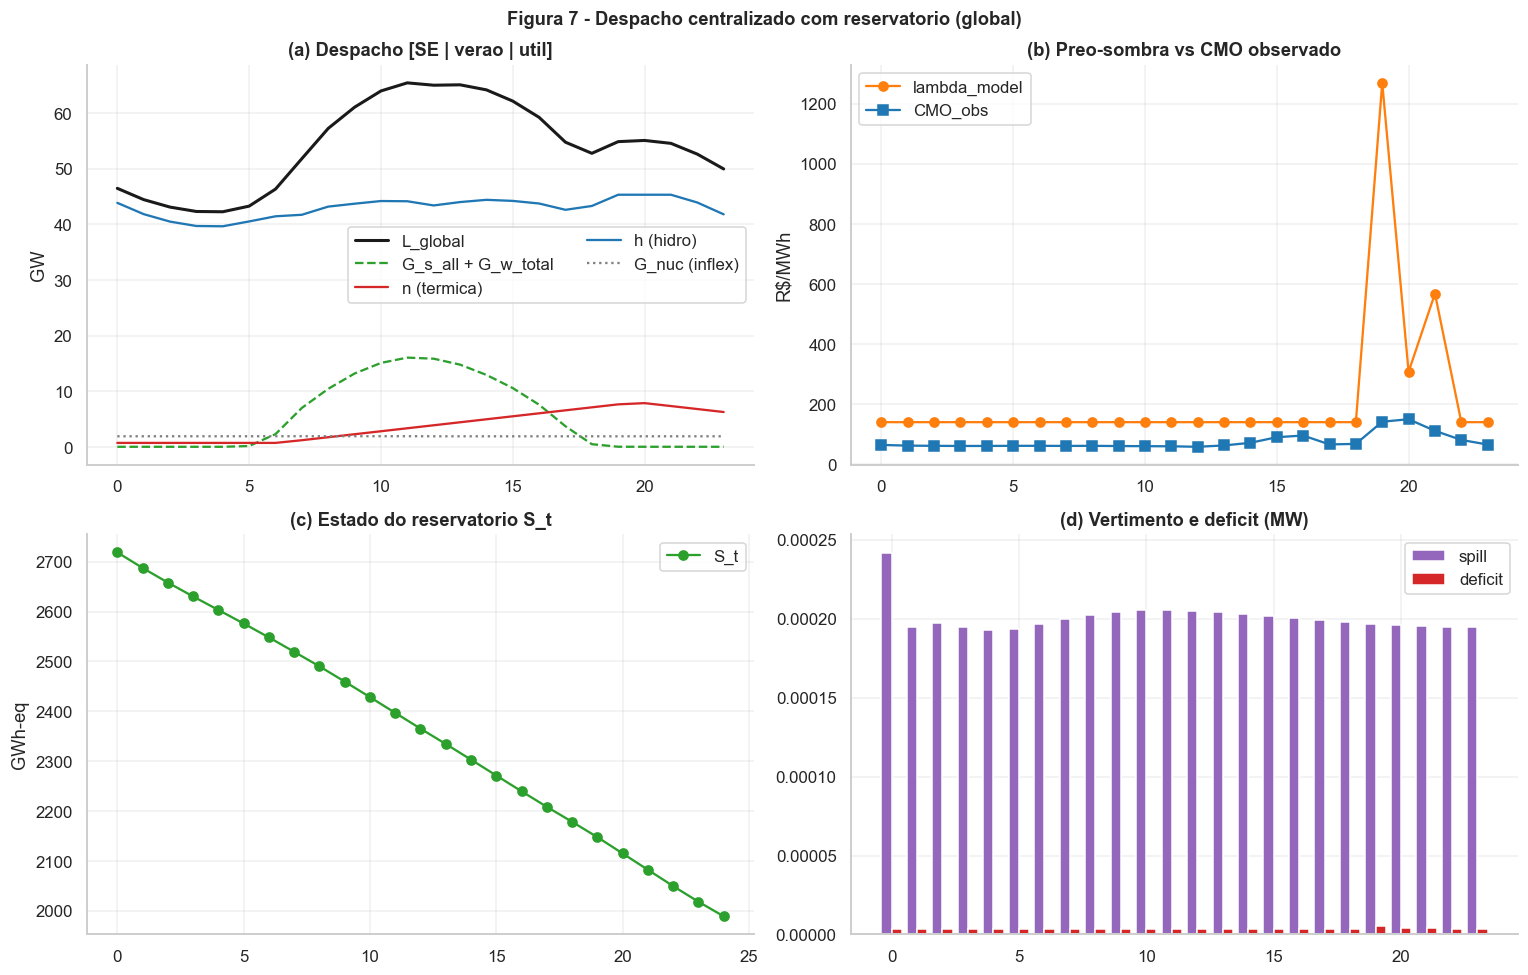

In [16]:
key = ("SE", "verao", "util")
if key in results_disp:
    r = results_disp[key]
    prof = typical_day(panel, *key).ffill().bfill().fillna(0.0)
    hours = np.arange(24)
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    ax = axes[0, 0]
    ax.plot(hours, prof[DEFAULT_LOAD_COL]/1000, "k-", lw=2, label=DEFAULT_LOAD_COL)
    ax.plot(hours, (prof[DEFAULT_SOLAR_COL] + prof["G_w_total"])/1000, "--", color="#2ca02c", label=f"{DEFAULT_SOLAR_COL} + G_w_total")
    ax.plot(hours, r["n"]/1000, color="#d62728", label="n (termica)")
    ax.plot(hours, r["h"]/1000, color="#1f77b4", label="h (hidro)")
    ax.plot(hours, prof["G_nuc_inflex"]/1000, color="#7f7f7f", ls=":", label="G_nuc (inflex)")
    ax.set_title("(a) Despacho [SE | verao | util]"); ax.set_ylabel("GW"); ax.legend(ncols=2); ax.grid(alpha=.3)
    ax = axes[0, 1]
    ax.plot(hours, r["lambda_model"], "o-", color="#ff7f0e", label="lambda_model")
    ax.plot(hours, prof["CMO_obs"], "s-", color="#1f77b4", label="CMO_obs")
    ax.set_title("(b) Preo-sombra vs CMO observado"); ax.set_ylabel("R$/MWh"); ax.legend(); ax.grid(alpha=.3)
    ax = axes[1, 0]
    ax.plot(np.arange(len(r["S"])), r["S"]/1000, "-o", color="#2ca02c", label="S_t")
    ax.set_title("(c) Estado do reservatorio S_t"); ax.set_ylabel("GWh-eq"); ax.legend(); ax.grid(alpha=.3)
    ax = axes[1, 1]
    ax.bar(hours - 0.2, r["spill"], width=0.4, color="#9467bd", label="spill")
    ax.bar(hours + 0.2, r["deficit"], width=0.4, color="#d62728", label="deficit")
    ax.set_title("(d) Vertimento e deficit (MW)"); ax.legend(); ax.grid(alpha=.3)
    fig.suptitle(f"Figura 7 - Despacho centralizado com reservatorio ({DEFAULT_SCOPE})", fontsize=12, fontweight="bold")
    fig.tight_layout(); fig.savefig(FIG_DIR / "fig07_despacho_dia_tipico_SE.png", bbox_inches="tight"); plt.show()


## 15. Modelo situacional — reescrito

In [17]:
# Templates SIN - 8 dias tipicos (4 estacoes - 2 tipos de dia)
agg = panel.groupby("din_instante", as_index=False).agg(
    L_dispatch=(DEFAULT_LOAD_COL, "sum"), G_s_dispatch=(DEFAULT_SOLAR_COL, "sum"),
    G_w_total=("G_w_total", "sum"), G_h_total=("G_h_total", "sum"),
    G_th_total=("G_th_total", "sum"), G_nuc_inflex=("G_nuc_inflex", "sum"),
)
agg = add_calendar(agg)
typ_sin = (agg.groupby(["estacao", "tipo_dia_g", "hora"], observed=False)
    .agg(L=("L_dispatch", "mean"), Gs=("G_s_dispatch", "mean"), Gw=("G_w_total", "mean"), Gh=("G_h_total", "mean"), Gth=("G_th_total", "mean"), Gnuc=("G_nuc_inflex", "mean"))
    .reindex(pd.MultiIndex.from_product([SEASON_ORDER, ["util", "fim_semana_feriado"], range(24)], names=["estacao", "tipo_dia_g", "hora"]))
    .ffill().bfill().reset_index())
blocks = []
for est in SEASON_ORDER:
    for td in ["util", "fim_semana_feriado"]:
        d = typ_sin.query("estacao == @est and tipo_dia_g == @td").sort_values("hora").copy()
        d["bloco"] = f"{est}-{td}"; blocks.append(d)
template = pd.concat(blocks, ignore_index=True)
T_SIT = len(template); N_BLOCKS = T_SIT // 24
K_S_SIT = float(K_eff.loc[:, "K_s_eff_p99"].sum())
K_W_SIT = float(K_eff.loc[:, "K_w_eff_p99"].sum())
K_TH_SIT = float(K_eff.loc[:, "K_th_eff_p99"].sum())
K_NUC_SIT = float(K_eff.loc[:, "K_nuc_eff_p99"].sum())
K_H_SIT_inst = float(K_eff.loc[:, "K_h_eff_p99"].sum())
a_s_t = (template["Gs"].values / max(K_S_SIT, 1e-6)).clip(0, 1.5)
a_w_t = (template["Gw"].values / max(K_W_SIT, 1e-6)).clip(0, 1.5)
Gw_exog = a_w_t * K_W_SIT
G_nuc_t = template["Gnuc"].values
L_t_sit = template["L"].values
B_h_daily = float(template.groupby("bloco")["Gh"].sum().mean())
A_total_per_hour = A_daily_avg
inflow_h_sit = np.tile(np.full(24, A_total_per_hour), N_BLOCKS)
S_max_sit = 24 * K_H_SIT_inst * 10.0
S_init_sit = 0.5 * S_max_sit
print(f"T_SIT={T_SIT}h | N_BLOCKS={N_BLOCKS}")
print(f"Situacional usa carga={DEFAULT_LOAD_COL}, solar={DEFAULT_SOLAR_COL}")
print(f"K_S_SIT={K_S_SIT/1000:.1f}GW | K_TH_SIT={K_TH_SIT/1000:.1f}GW | K_H_SIT={K_H_SIT_inst/1000:.1f}GW | K_NUC_SIT={K_NUC_SIT/1000:.1f}GW")
print(f"a_s_t mean={a_s_t.mean():.3f} | a_w_t mean={a_w_t.mean():.3f}")
y_sit = panel.dropna(subset=["CMO_obs"])["CMO_obs"].values
x_sit = panel.dropna(subset=["CMO_obs"])["G_th_total"].values
A_lst = np.column_stack([np.ones_like(x_sit), x_sit])
cf_sit, *_ = np.linalg.lstsq(A_lst, y_sit, rcond=None)
c1_sit = max(float(cf_sit[0]), 50.0)
c2_sit = max(float(cf_sit[1]), 1e-6)
print(f"c1_sit={c1_sit:.1f} | c2_sit={c2_sit:.6f}")


T_SIT=192h | N_BLOCKS=8
Situacional usa carga=L_global, solar=G_s_all
K_S_SIT=37.2GW | K_TH_SIT=16.5GW | K_H_SIT=85.7GW | K_NUC_SIT=2.0GW
a_s_t mean=0.270 | a_w_t mean=0.544
c1_sit=123.5 | c2_sit=0.023424


In [18]:
def solve_situational(K1: float, kappa: float = 0.0, hyd_scale: float = 1.0) -> dict:
    """Modelo situacional finito com curtailment solar e nuclear inflexivel."""
    T = T_SIT
    K2 = kappa * K1
    g1 = cp.Variable(T, nonneg=True); g2 = cp.Variable(T, nonneg=True)
    curt1 = cp.Variable(T, nonneg=True); curt2 = cp.Variable(T, nonneg=True)
    n = cp.Variable(T, nonneg=True); h = cp.Variable(T, nonneg=True)
    spill = cp.Variable(T, nonneg=True); curt_res = cp.Variable(T, nonneg=True)
    defc = cp.Variable(T, nonneg=True); S = cp.Variable(T + 1, nonneg=True)
    cost = (c1_sit * cp.sum(n) + 0.5 * c2_sit * cp.sum_squares(n)
            + PARAMS["water_opportunity_cost"] * cp.sum(h)
            + PARAMS["pi_curt_RS_per_MWh"] * (cp.sum(curt1) + cp.sum(curt2) + cp.sum(curt_res))
            + PARAMS["pi_def_RS_per_MWh"] * cp.sum(defc)
            - PARAMS["shadow_water_value_proxy"] * S[T])
    bal = (g1 + g2 + Gw_exog + h + n + G_nuc_t) - (L_t_sit + curt_res - defc) == 0
    cons = [bal, g1 + curt1 == K1 * a_s_t, g2 + curt2 == K2 * a_s_t, n <= K_TH_SIT,
            h <= K_H_SIT_inst * hyd_scale, S[0] == S_init_sit, S <= S_max_sit * hyd_scale]
    for t in range(T):
        cons.append(S[t + 1] == S[t] + inflow_h_sit[t] * hyd_scale - h[t] - spill[t])
    for kbl in range(N_BLOCKS):
        cons.append(cp.sum(h[kbl*24:(kbl+1)*24]) <= B_h_daily * hyd_scale)
    prob = cp.Problem(cp.Minimize(cost), cons)
    prob.solve(solver=cp.CLARABEL)
    lam = -bal.dual_value if bal.dual_value is not None else np.full(T, np.nan)
    G1 = np.asarray(g1.value if g1.value is not None else np.zeros(T), dtype=float)
    G2 = np.asarray(g2.value if g2.value is not None else np.zeros(T), dtype=float)
    CU1 = np.asarray(curt1.value if curt1.value is not None else np.zeros(T), dtype=float)
    CU2 = np.asarray(curt2.value if curt2.value is not None else np.zeros(T), dtype=float)

    def capture_stats(K, G, lambda_model):
        if K <= 0 or np.nansum(G) <= 1e-9:
            return 0.0, np.nan, np.nan
        Rev_model = float(np.nansum(lambda_model * G))
        R_cap_model = Rev_model / float(np.nansum(G))
        P_avg = float(np.nanmean(lambda_model))
        F_capture_model = R_cap_model / P_avg if P_avg > 0 else np.nan
        return Rev_model, R_cap_model, F_capture_model

    Rev_1_model, R_cap_1_model, F_capture_1_model = capture_stats(K1, G1, lam)
    Rev_2_model, R_cap_2_model, F_capture_2_model = capture_stats(K2, G2, lam)
    P_avg = float(np.nanmean(lam))
    return {
        "status": prob.status, "cost": float(prob.value), "g1": G1, "g2": G2,
        "curt_solar_1": CU1, "curt_solar_2": CU2,
        "n": np.asarray(n.value), "h": np.asarray(h.value), "spill": np.asarray(spill.value),
        "curt_resid": np.asarray(curt_res.value), "deficit": np.asarray(defc.value), "S": np.asarray(S.value),
        "lambda_model": np.asarray(lam), "K1": K1, "K2": K2,
        "Rev_1_model": Rev_1_model, "Rev_2_model": Rev_2_model,
        "R_cap_1_model": R_cap_1_model, "R_cap_2_model": R_cap_2_model,
        "F_capture_1_model": F_capture_1_model, "F_capture_2_model": F_capture_2_model,
        "P_avg_lambda": P_avg,
        "curt_rate_1": float(CU1.sum() / max((K1 * a_s_t).sum(), 1e-9)) if K1 > 0 else np.nan,
        "curt_rate_2": float(CU2.sum() / max((K2 * a_s_t).sum(), 1e-9)) if K2 > 0 else np.nan,
    }

KAPPAS = [0.0, 0.25, 0.5, 1.0, 2.0]
results_sit = {k: solve_situational(K_S_SIT, k) for k in KAPPAS}
rows = []
for k, r in results_sit.items():
    rows.append({
        "kappa": k, "cost": r["cost"], "G_th_total": float(r["n"].sum()), "G_h_used": float(r["h"].sum()),
        "spill_total": float(r["spill"].sum()), "S_T_residual": float(r["S"][-1]),
        "curt_solar_1": float(r["curt_solar_1"].sum()), "curt_solar_2": float(r["curt_solar_2"].sum()),
        "curt_solar_total": float(r["curt_solar_1"].sum() + r["curt_solar_2"].sum()),
        "curt_rate_1": r["curt_rate_1"], "curt_rate_2": r["curt_rate_2"],
        "curt_resid_total": float(r["curt_resid"].sum()), "deficit_total": float(r["deficit"].sum()),
        "lambda_model_mean": r["P_avg_lambda"], "Rev_1_model": r["Rev_1_model"], "Rev_2_model": r["Rev_2_model"],
        "R_cap_1_model": r["R_cap_1_model"], "R_cap_2_model": r["R_cap_2_model"],
        "F_capture_1_model": r["F_capture_1_model"], "F_capture_2_model": r["F_capture_2_model"],
    })
sit_summary = pd.DataFrame(rows)
sit_summary.to_csv(TABLE_DIR / "tab_situacional_kappa.csv", index=False, float_format="%.4f")
sit_summary.to_csv(TABLE_DIR / "tab_situational_kappa_sensitivity.csv", index=False, float_format="%.4f")
print(sit_summary.round(3).to_string(index=False))


 kappa          cost  G_th_total    G_h_used  spill_total  S_T_residual  curt_solar_1  curt_solar_2  curt_solar_total  curt_rate_1  curt_rate_2  curt_resid_total  deficit_total  lambda_model_mean  Rev_1_model  Rev_2_model  R_cap_1_model  R_cap_2_model  F_capture_1_model  F_capture_2_model
  0.00  1.969610e+09 1927442.240 8618009.094        0.014  11326962.954         0.000         0.000             0.000        0.000          NaN             0.000     402081.960           1480.226 2.939689e+09 0.000000e+00       1524.309            NaN              1.030                NaN
  0.25  1.376358e+09 1686800.518 8519203.586        0.010  11425768.466         0.000         0.000             0.001        0.000        0.000             0.000     259394.576           1077.002 2.133695e+09 5.334236e+08       1106.379       1106.379              1.027              1.027
  0.50  9.497487e+08 1427059.386 8388347.175        0.004  11556624.883         0.001         0.001             0.002        0.000

### 15.1 Diagnóstico de factibilidade e déficit

Tabela `tab_feasibility_diagnostics.csv` por cenário: carga total, geração
disponível por fonte, capacidade térmica efetiva, orçamento hidráulico,
geração inflexível, déficit total, horas com déficit, `lambda_model` médio
e máximo.

Se algum cenário gera déficit > 0 com folga térmica + hidro disponíveis,
isso é artefato de modelagem (rampa muito apertada, orçamento muito baixo,
penalidade mal calibrada). Se a infactibilidade é genuína (carga supera
capacidade física agregada), rotulamos como **cenário de estresse**.


In [19]:
diag_rows = []
for k, r in results_sit.items():
    L_total = float(L_t_sit.sum())
    Gs_disp = float((K_S_SIT * a_s_t).sum() + r["K2"] * a_s_t.sum())
    Gw_disp = float(Gw_exog.sum())
    G_nuc_disp = float(G_nuc_t.sum())
    K_TH_eff_total = K_TH_SIT * T_SIT
    B_h_total = B_h_daily * N_BLOCKS
    deficit_h = int((r["deficit"] > 1.0).sum())
    deficit_total = float(r["deficit"].sum())
    cap_supply = (K_TH_eff_total + B_h_total + Gs_disp + Gw_disp + G_nuc_disp)
    # Etiquetagem em 3 níveis:
    #   ok                    : sem déficit
    #   modelagem_artefato    : déficit > 0 mas supply agregado >= demanda
    #                            (deficit vem de descasamento intra-hora: pico solar
    #                            no meio-dia, pico de carga à noite, etc.)
    #   estresse_estrutural   : supply agregado < demanda
    if deficit_total < 1e3:
        lbl = "ok"
    elif cap_supply >= L_total:
        lbl = "modelagem_artefato"
    else:
        lbl = "estresse_estrutural"
    diag_rows.append({
        "scenario": f"kappa={k}",
        "L_total_MWh":        L_total,
        "Gs_avail_MWh":       Gs_disp,
        "Gw_avail_MWh":       Gw_disp,
        "G_nuc_inflex_MWh":   G_nuc_disp,
        "K_th_eff_total_MWh": K_TH_eff_total,
        "E_hydro_budget_MWh": B_h_total,
        "supply_agg_MWh":     cap_supply,
        "supply_minus_load":  cap_supply - L_total,
        "deficit_total_MWh":  deficit_total,
        "deficit_hours":      deficit_h,
        "lambda_mean":        float(np.nanmean(r["lambda_model"])),
        "lambda_max":         float(np.nanmax(r["lambda_model"])),
        "label":              lbl,
    })
diag = pd.DataFrame(diag_rows)
diag.to_csv(TABLE_DIR / "tab_feasibility_diagnostics.csv", index=False, float_format="%.2f")
print(diag.round(0).to_string(index=False))

n_stress = int((diag["label"] == "estresse_estrutural").sum())
n_artefato = int((diag["label"] == "modelagem_artefato").sum())
if n_stress > 0:
    print(f"\n[INFO] {n_stress} cenário(s) com `estresse_estrutural` (supply agregado < demanda).")
if n_artefato > 0:
    print(f"[INFO] {n_artefato} cenário(s) com `modelagem_artefato` "
          "(supply agregado >= demanda, mas descasamento intra-hora gera déficit residual).")


  scenario  L_total_MWh  Gs_avail_MWh  Gw_avail_MWh  G_nuc_inflex_MWh  K_th_eff_total_MWh  E_hydro_budget_MWh  supply_agg_MWh  supply_minus_load  deficit_total_MWh  deficit_hours  lambda_mean  lambda_max              label
 kappa=0.0   15743772.0     1928538.0     2522495.0          345206.0           3160591.0           8729082.0      16685912.0           942140.0           402082.0             72       1480.0      3500.0 modelagem_artefato
kappa=0.25   15743772.0     2410673.0     2522495.0          345206.0           3160591.0           8729082.0      17168046.0          1424274.0           259395.0             48       1077.0      3500.0 modelagem_artefato
 kappa=0.5   15743772.0     2892808.0     2522495.0          345206.0           3160591.0           8729082.0      17650181.0          1906409.0           167858.0             24        671.0      3500.0 modelagem_artefato
 kappa=1.0   15743772.0     3857077.0     2522495.0          345206.0           3160591.0           8729082.

### 15.2 Figura 9 - Sensibilidade situacional a kappa

Com `kappa = 0`, o segundo agente solar nao existe; logo `Rev_2_model = 0` e as metricas capturadas por MWh/fator de captura do agente 2 ficam como `NaN`.


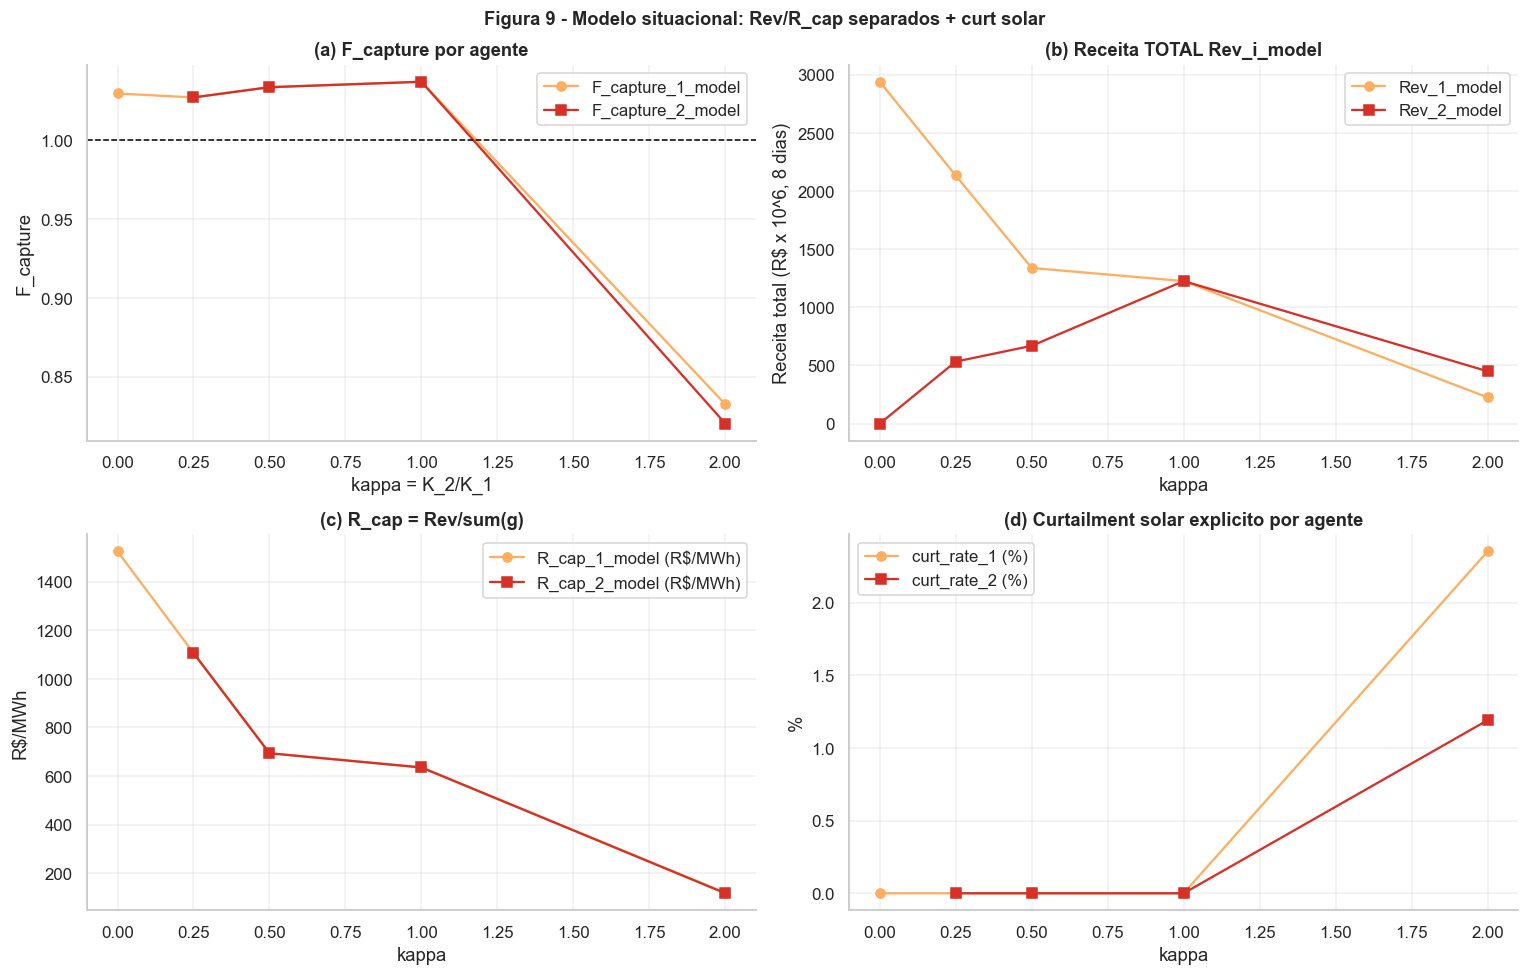

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ax = axes[0, 0]
ax.plot(sit_summary["kappa"], sit_summary["F_capture_1_model"], "o-", color="#fdae61", label="F_capture_1_model")
ax.plot(sit_summary["kappa"], sit_summary["F_capture_2_model"], "s-", color="#d73027", label="F_capture_2_model")
ax.axhline(1.0, color="black", ls="--", lw=1)
ax.set_xlabel("kappa = K_2/K_1"); ax.set_ylabel("F_capture"); ax.set_title("(a) F_capture por agente"); ax.legend(); ax.grid(alpha=.3)
ax = axes[0, 1]
ax.plot(sit_summary["kappa"], sit_summary["Rev_1_model"]/1e6, "o-", color="#fdae61", label="Rev_1_model")
ax.plot(sit_summary["kappa"], sit_summary["Rev_2_model"]/1e6, "s-", color="#d73027", label="Rev_2_model")
ax.set_xlabel("kappa"); ax.set_ylabel("Receita total (R$ x 10^6, 8 dias)"); ax.set_title("(b) Receita TOTAL Rev_i_model"); ax.legend(); ax.grid(alpha=.3)
ax = axes[1, 0]
ax.plot(sit_summary["kappa"], sit_summary["R_cap_1_model"], "o-", color="#fdae61", label="R_cap_1_model (R$/MWh)")
ax.plot(sit_summary["kappa"], sit_summary["R_cap_2_model"], "s-", color="#d73027", label="R_cap_2_model (R$/MWh)")
ax.set_xlabel("kappa"); ax.set_ylabel("R$/MWh"); ax.set_title("(c) R_cap = Rev/sum(g)"); ax.legend(); ax.grid(alpha=.3)
ax = axes[1, 1]
ax.plot(sit_summary["kappa"], 100*sit_summary["curt_rate_1"], "o-", color="#fdae61", label="curt_rate_1 (%)")
ax.plot(sit_summary["kappa"], 100*sit_summary["curt_rate_2"], "s-", color="#d73027", label="curt_rate_2 (%)")
ax.set_xlabel("kappa"); ax.set_ylabel("%"); ax.set_title("(d) Curtailment solar explicito por agente"); ax.legend(); ax.grid(alpha=.3)
fig.suptitle("Figura 9 - Modelo situacional: Rev/R_cap separados + curt solar", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig09_situacional_sensibilidade.png", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig_situational_kappa_sensitivity.png", bbox_inches="tight")
plt.show()


## 16. Sensibilidade hidrológica (cenários seca/base/úmida)

     cenario  cost (R$ x10^6)  G_th_total (GWh)  G_h_used (GWh)  spill (GWh)  curt_solar_total (GWh)  deficit (MWh)  lambda_model_mean (R$/MWh)
 seca (-30%)          4899.51           2667.59         6110.35       773.17                    0.14     1205552.92                     2315.86
        base           949.75           1427.06         8388.35         0.00                    0.00      167857.51                      671.45
umida (+30%)           152.55            287.46         9695.81      1706.15                    0.01           0.14                      142.76


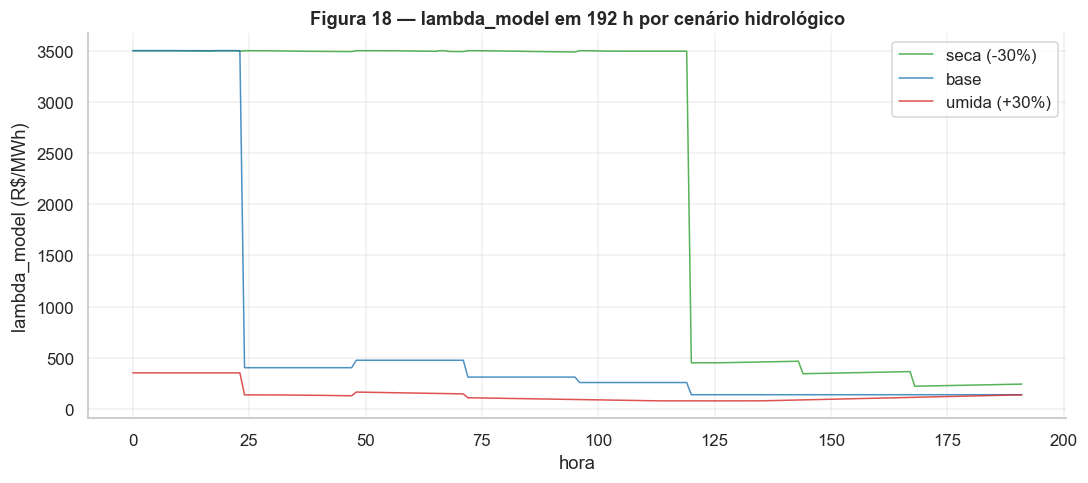

In [21]:
SCEN_H = {"seca (-30%)": 0.7, "base": 1.0, "umida (+30%)": 1.3}
hidro_res = {name: solve_situational(K_S_SIT, kappa=0.5, hyd_scale=sc)
             for name, sc in SCEN_H.items()}

rows = []
for name, r in hidro_res.items():
    rows.append({
        "cenario": name,
        "cost (R$ x10^6)":            r["cost"] / 1e6,
        "G_th_total (GWh)":            r["n"].sum() / 1e3,
        "G_h_used (GWh)":              r["h"].sum() / 1e3,
        "spill (GWh)":                 r["spill"].sum() / 1e3,
        "curt_solar_total (GWh)":      (r["curt_solar_1"].sum() + r["curt_solar_2"].sum())/1e3,
        "deficit (MWh)":               r["deficit"].sum(),
        "lambda_model_mean (R$/MWh)":  r["P_avg_lambda"],
    })
val_agua = pd.DataFrame(rows)
val_agua.to_csv(TABLE_DIR / "tab_valor_agua_cenarios.csv", index=False, float_format="%.3f")
print(val_agua.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
for (name, r), color in zip(hidro_res.items(), ["#2ca02c", "#1f77b4", "#d62728"]):
    ax.plot(r["lambda_model"], lw=1.0, alpha=.8, color=color, label=name)
ax.set_title("Figura 18 — lambda_model em 192 h por cenário hidrológico")
ax.set_xlabel("hora"); ax.set_ylabel("lambda_model (R$/MWh)")
ax.legend(); ax.grid(alpha=.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig18_valor_agua.png", bbox_inches="tight")
plt.show()


## 17. Utilitário geográfico — polígonos esquemáticos dos subsistemas

Tentamos primeiro carregar um shapefile/geopackage em
`data/geospatial/brasil_subsistemas.geojson`; se ausente, caímos para polígonos
esquemáticos (mesma estrutura de chave por subsistema).


In [22]:
SUBSYS_CENTROIDS = {
    "N":  (-5.0,  -55.0),
    "NE": (-9.0,  -40.0),
    "SE": (-18.5, -47.0),
    "S":  (-28.0, -52.0),
}
SUBSYS_POLYGONS = {
    "N":  [(-74, -10), (-74,   5), (-50,  5), (-44, -2), (-44, -10)],
    "NE": [(-46, -18), (-46,  -2), (-34, -3), (-34, -17), (-40, -18)],
    "SE": [(-58, -25), (-58, -15), (-48, -10), (-44, -10), (-39, -20),
           (-40, -24), (-50, -25)],
    "S":  [(-58, -34), (-58, -25), (-50, -25), (-48, -29), (-50, -34)],
}

GEO_FILE = GEO_DIR / "brasil_subsistemas.geojson"
USE_GEOJSON = GEO_FILE.exists()
if USE_GEOJSON:
    try:
        gj = json.loads(GEO_FILE.read_text(encoding="utf-8"))
        SUBSYS_POLYGONS_GJ = {}
        for feat in gj.get("features", []):
            key = feat.get("properties", {}).get("id_subsistema")
            geom = feat.get("geometry", {})
            if key and geom.get("type") == "Polygon":
                SUBSYS_POLYGONS_GJ[key] = [(c[0], c[1]) for c in geom["coordinates"][0]]
        if set(SUBSYS_POLYGONS_GJ.keys()) >= set(SUBSYS_ORDER):
            SUBSYS_POLYGONS = SUBSYS_POLYGONS_GJ
            print(f"[geo] Usando shapefile/geojson: {GEO_FILE}")
        else:
            USE_GEOJSON = False
    except Exception as e:
        print(f"[geo] falha ao ler {GEO_FILE}: {e} -> usando esquemáticos")
        USE_GEOJSON = False
if not USE_GEOJSON:
    print("[geo] Usando polígonos esquemáticos (data/geospatial/brasil_subsistemas.geojson ausente)")


def plot_subsystem_map(ax, value_per_subsys: dict, *,
                       cmap_name: str = "YlOrRd", title: str = "",
                       label_fmt: str = ".1f", label_unit: str = "",
                       vmin: float | None = None, vmax: float | None = None) -> None:
    """Mapa esquemático do Brasil com cor por subsistema, valor anotado."""
    cmap = cm.get_cmap(cmap_name)
    vals = np.array([value_per_subsys.get(s, np.nan) for s in SUBSYS_ORDER])
    vmin = vmin if vmin is not None else np.nanmin(vals)
    vmax = vmax if vmax is not None else np.nanmax(vals)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    patches, colors = [], []
    for sub in SUBSYS_ORDER:
        poly = SUBSYS_POLYGONS[sub]
        patches.append(MplPolygon(poly, closed=True))
        v = value_per_subsys.get(sub, np.nan)
        colors.append(cmap(norm(v)) if np.isfinite(v) else (0.9, 0.9, 0.9, 1.0))
    ax.add_collection(PatchCollection(patches, facecolor=colors,
                                      edgecolor="black", linewidth=1.0, alpha=0.85))
    for sub in SUBSYS_ORDER:
        lat, lon = SUBSYS_CENTROIDS[sub]
        v = value_per_subsys.get(sub, np.nan)
        ax.plot(lon, lat, "ko", markersize=5)
        label = f"{sub}\n{v:{label_fmt}}{label_unit}" if np.isfinite(v) else f"{sub}\n—"
        ax.annotate(label, (lon, lat), xytext=(0, -15), textcoords="offset points",
                    ha="center", fontsize=9, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))
    ax.set_xlim(-76, -32); ax.set_ylim(-36, 8)
    ax.set_aspect("equal")
    ax.set_xlabel("longitude (°)"); ax.set_ylabel("latitude (°)")
    ax.set_title(title); ax.grid(alpha=.2)
    sm = cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=.6)


[geo] Usando polígonos esquemáticos (data/geospatial/brasil_subsistemas.geojson ausente)


## 18. **Mean Field Game locacional discreto**


In [23]:
# Perfis horarios tipicos por subsistema (dia tipico anual)
typ_loc = (panel.groupby(["id_subsistema", "hora"])
                .agg(L=(DEFAULT_LOAD_COL, "mean"), Gs=(DEFAULT_SOLAR_COL, "mean"), Gw=("G_w_total", "mean"),
                     Gh=("G_h_total", "mean"), Gth=("G_th_total", "mean"), Gnuc=("G_nuc_inflex", "mean"), CMO_obs=("CMO_obs", "mean"))
                .reset_index())

# Intercmbio: limites por corredor
intc_raw = pd.read_csv(paths.interc_interno_path, sep=";", parse_dates=["din_instante"])
intc_raw = intc_raw[intc_raw["din_instante"].between(DATE_MIN, DATE_MAX)]
intc_raw["o"] = intc_raw["nom_subsistema_origem"].astype(str).map(canonical_subsys)
intc_raw["d"] = intc_raw["nom_subsistema_destino"].astype(str).map(canonical_subsys)
flow_lim = (intc_raw.groupby(["o", "d"])["val_intercambiomwmed"].apply(lambda x: float(np.nanquantile(x.abs(), 0.99))).reset_index().rename(columns={"val_intercambiomwmed": "F_max"}))
ALL_LINKS = [("N", "NE"), ("N", "SE"), ("NE", "SE"), ("SE", "S")]
F_MAX = {(o, d): float(flow_lim.query("o == @o and d == @d")["F_max"].iloc[0]) if len(flow_lim.query("o == @o and d == @d")) else 0.0 for (o, d) in ALL_LINKS}
print("F_max por corredor:", {k: f"{v:.0f}" for k, v in F_MAX.items()})

HOURS = 24
def _arr(sub, col):
    s = typ_loc.query("id_subsistema == @sub").set_index("hora").sort_index()[col].reindex(range(HOURS))
    return s.ffill().bfill().fillna(0.0).values

L_lt = {s: _arr(s, "L") for s in SUBSYS_ORDER}
Gw_lt = {s: _arr(s, "Gw") for s in SUBSYS_ORDER}
Gnuc_lt = {s: _arr(s, "Gnuc") for s in SUBSYS_ORDER}
Havail_lt = {s: _arr(s, "Gh") for s in SUBSYS_ORDER}
a_s_loc = {s: (_arr(s, "Gs") / max(K_eff.loc[s, "K_s_eff_p99"], 1e-6)).clip(0, 1.5) for s in SUBSYS_ORDER}
K_TH_loc = {s: float(K_eff.loc[s, "K_th_eff_p99"]) for s in SUBSYS_ORDER}
K_H_loc = {s: float(K_eff.loc[s, "K_h_eff_p99"]) for s in SUBSYS_ORDER}

c1_loc, c2_loc = {}, {}
for s in SUBSYS_ORDER:
    g = panel[(panel["id_subsistema"] == s)].dropna(subset=["CMO_obs"])
    if len(g) < 30:
        c1_loc[s], c2_loc[s] = c1_sit, c2_sit
        continue
    y = g["CMO_obs"].values; x = g["G_th_total"].values
    A_lst = np.column_stack([np.ones_like(x), x])
    cf, *_ = np.linalg.lstsq(A_lst, y, rcond=None)
    c1_loc[s] = max(float(cf[0]), 50.0)
    c2_loc[s] = max(float(cf[1]), 5e-3)
print("c1_loc:", {s: f"{c1_loc[s]:.1f}" for s in SUBSYS_ORDER})
print(f"MFG locacional usa carga={DEFAULT_LOAD_COL}, solar={DEFAULT_SOLAR_COL}")


F_max por corredor: {('N', 'NE'): '5651', ('N', 'SE'): '9580', ('NE', 'SE'): '7629', ('SE', 'S'): '8576'}
c1_loc: {'N': '50.0', 'NE': '84.3', 'SE': '96.4', 'S': '141.1'}
MFG locacional usa carga=L_global, solar=G_s_all


In [24]:
def clearing_locacional(G_s_lt: dict, *,
                       water_opportunity_cost: float = 80.0,
                       pi_curt: float = 30.0, pi_def: float = 3500.0) -> dict:
    """Clearing locacional 24h. Recebe oferta solar agregada G_s_lt[ell] (vinda do MFG).

    Balanço por subsistema:
      G_s + Gw + Gnuc + h + n + (inflow - outflow) = L + curt - deficit

    Retorna lambda_loc[ell, t] = -bal.dual_value.
    """
    locs = SUBSYS_ORDER
    n = {l: cp.Variable(HOURS, nonneg=True) for l in locs}
    h = {l: cp.Variable(HOURS, nonneg=True) for l in locs}
    curt = {l: cp.Variable(HOURS, nonneg=True) for l in locs}
    defc = {l: cp.Variable(HOURS, nonneg=True) for l in locs}
    F = {(o, d): cp.Variable(HOURS) for (o, d) in ALL_LINKS}

    cost = 0
    for l in locs:
        cost += (c1_loc[l] * cp.sum(n[l]) + 0.5 * c2_loc[l] * cp.sum_squares(n[l])
                 + water_opportunity_cost * cp.sum(h[l])
                 + pi_def * cp.sum(defc[l]) + pi_curt * cp.sum(curt[l]))

    bal = {}
    cons = []
    for l in locs:
        inflow  = sum(F[(o, d)] for (o, d) in ALL_LINKS if d == l)
        outflow = sum(F[(o, d)] for (o, d) in ALL_LINKS if o == l)
        bal[l] = (G_s_lt[l] + Gw_lt[l] + Gnuc_lt[l] + h[l] + n[l] + inflow - outflow) \
                 == (L_lt[l] + curt[l] - defc[l])
        cons.append(bal[l])
        cons.append(n[l] <= K_TH_loc[l])
        cons.append(h[l] <= Havail_lt[l])
        cons.append(cp.sum(h[l]) <= Havail_lt[l].sum() * 0.95)
    for (o, d) in ALL_LINKS:
        cons.append(F[(o, d)] <=  F_MAX[(o, d)])
        cons.append(F[(o, d)] >= -F_MAX[(o, d)])

    prob = cp.Problem(cp.Minimize(cost), cons)
    prob.solve(solver=cp.CLARABEL)

    lam_l = {l: -bal[l].dual_value if bal[l].dual_value is not None else np.full(HOURS, np.nan)
             for l in locs}
    return {
        "status": prob.status, "cost": float(prob.value),
        "n":    {l: n[l].value    for l in locs},
        "h":    {l: h[l].value    for l in locs},
        "curt": {l: curt[l].value for l in locs},
        "deficit": {l: defc[l].value for l in locs},
        "F":    {k: F[k].value    for k in F},
        "lambda_loc": lam_l,
    }


### 18.1 MFG - espaco de estados, acoes, custos e dinamica


In [25]:
# Grade discreta
LOCS = SUBSYS_ORDER
N_LOC = len(LOCS)
K_BINS = np.arange(0, 9)
N_K = len(K_BINS)
THETA_BINS = np.array([0, 1, 2])
PROD = {0: 0.90, 1: 1.00, 2: 1.10}
N_THETA = len(THETA_BINS)
DELTA_K_ACTIONS = np.array([-1, 0, +1])
ACTIONS = [(int(delta_k), int(ell_next_idx)) for delta_k in DELTA_K_ACTIONS for ell_next_idx in range(N_LOC)]

K_S_OBS_TOTAL = float(K_eff.loc[:, "K_s_eff_p99"].sum())
N_AGENTS = 100.0
m0 = np.zeros((N_LOC, N_K, N_THETA))
for i, ell in enumerate(LOCS):
    share = K_eff.loc[ell, "K_s_eff_p99"] / K_S_OBS_TOTAL
    m0[i, 4, 1] = share
assert abs(m0.sum() - 1.0) < 1e-9
cap_unit = K_S_OBS_TOTAL / (N_AGENTS * 4.0)
print(f"cap_unit = {cap_unit:.1f} MW por unidade de bin (N_AGENTS={N_AGENTS:.0f})")

WACC = 0.08; VIDA = 25
FATOR_ANUAL = WACC * (1 + WACC)**VIDA / ((1 + WACC)**VIDA - 1)
capex_reg = {"N": 4.2, "NE": 3.6, "SE": 3.8, "S": 4.0}
conn_reg = {"N": 0.40, "NE": 0.30, "SE": 0.15, "S": 0.22}
om_reg = {"N": 0.084, "NE": 0.072, "SE": 0.076, "S": 0.080}
q_reg = {s: (capex_reg[s] + conn_reg[s]) * 1e6 * FATOR_ANUAL + om_reg[s] * 1e6 for s in SUBSYS_ORDER}
print("q_reg (R$/MW/ano):", {s: f"{q_reg[s]:,.0f}" for s in SUBSYS_ORDER})

CHI_ADJ = 2000.0
RHO_RELOC_SAME = 0.0
RHO_RELOC_OTHER = 500e6
rho_reloc = {(ell, ell_next): (RHO_RELOC_SAME if ell == ell_next else RHO_RELOC_OTHER) for ell in LOCS for ell_next in LOCS}
K_max_loc = {ell: max(2.0 * float(K_eff.loc[ell, "K_s_eff_p99"]), 2.0 * cap_unit) for ell in LOCS}
GAMMA_LOC_RS_PER_MW_YEAR = 5.0e6
EPS_DIFF = 0.01
print("K_max_loc (GW):", {s: f"{K_max_loc[s]/1000:.2f}" for s in LOCS})
print(f"Regularizacao: CHI_ADJ={CHI_ADJ}, RHO_RELOC_OTHER={RHO_RELOC_OTHER:,.0f}, GAMMA_LOC={GAMMA_LOC_RS_PER_MW_YEAR:,.0f}")

def capacity_by_location_from_m(m: np.ndarray) -> dict:
    caps = {}
    for i, ell in enumerate(LOCS):
        cap = sum(N_AGENTS * cap_unit * m[i, kb, tb] * K_BINS[kb] * PROD[THETA_BINS[tb]] for kb in range(N_K) for tb in range(N_THETA))
        caps[ell] = float(cap)
    return caps

def agg_solar_from_m(m: np.ndarray) -> dict:
    caps = capacity_by_location_from_m(m)
    return {ell: caps[ell] * a_s_loc[ell] for ell in LOCS}

def annual_revenue_per_MW(lam_loc_h: np.ndarray, ell: str) -> float:
    return float((lam_loc_h * a_s_loc[ell]).sum()) * 365.0

def investment_cost(ell_next: str, cap_MW: float) -> float:
    return q_reg[ell_next] * cap_MW

def adjustment_cost(delta_cap_MW: float) -> float:
    return CHI_ADJ * (delta_cap_MW ** 2)

def relocation_cost(ell: str, ell_next: str) -> float:
    return rho_reloc[(ell, ell_next)]

def curtailment_risk_cost(ell_next: str, cap_MW: float, K_loc_current: float) -> float:
    loc_congestion_penalty = GAMMA_LOC_RS_PER_MW_YEAR * (K_loc_current / max(K_max_loc[ell_next], 1e-9))**2
    return cap_MW * loc_congestion_penalty

def best_response_capacity_location(m: np.ndarray, lam_loc: dict) -> tuple[np.ndarray, np.ndarray]:
    """Para cada x=(ell,k,theta), escolhe a=(delta_k, ell_next)."""
    policy = np.zeros((N_LOC, N_K, N_THETA), dtype=int)
    profit = np.full((N_LOC, N_K, N_THETA), -np.inf)
    K_loc_current = capacity_by_location_from_m(m)
    rev_per_MW = {ell: annual_revenue_per_MW(lam_loc[ell], ell) for ell in LOCS}
    for i, ell in enumerate(LOCS):
        for kb in range(N_K):
            k_now = K_BINS[kb]
            for tb in range(N_THETA):
                prod = PROD[THETA_BINS[tb]]
                best_p = -np.inf; best_a_idx = 0
                for ai, (delta_k, ell_next_idx) in enumerate(ACTIONS):
                    ell_next = LOCS[ell_next_idx]
                    kb_next = int(np.clip(kb + delta_k, 0, N_K - 1))
                    k_next = K_BINS[kb_next]
                    cap_MW = cap_unit * k_next * prod
                    delta_cap_MW = cap_unit * (k_next - k_now) * prod
                    expected_revenue = rev_per_MW[ell_next] * cap_MW
                    inv = investment_cost(ell_next, cap_MW)
                    adj = adjustment_cost(delta_cap_MW)
                    reloc = relocation_cost(ell, ell_next)
                    risk = curtailment_risk_cost(ell_next, cap_MW, K_loc_current[ell_next])
                    p = expected_revenue - inv - adj - reloc - risk
                    if p > best_p:
                        best_p = p; best_a_idx = ai
                policy[i, kb, tb] = best_a_idx
                profit[i, kb, tb] = best_p
    return policy, profit

def forward_update(m: np.ndarray, policy: np.ndarray, eps: float = EPS_DIFF) -> np.ndarray:
    """m_next[ell_next, k_next, theta] += m[ell, k, theta] sob polotica otima."""
    m_new = np.zeros_like(m)
    for i in range(N_LOC):
        for kb in range(N_K):
            for tb in range(N_THETA):
                delta_k, ell_next_idx = ACTIONS[policy[i, kb, tb]]
                kb_next = int(np.clip(kb + delta_k, 0, N_K - 1))
                m_new[ell_next_idx, kb_next, tb] += m[i, kb, tb]
    m_uniform = np.full_like(m_new, 1.0 / m_new.size)
    m_new = (1 - eps) * m_new + eps * m_uniform
    m_new /= m_new.sum()
    return m_new


cap_unit = 93.0 MW por unidade de bin (N_AGENTS=100)
q_reg (R$/MW/ano): {'N': '514,922', 'NE': '437,347', 'SE': '446,031', 'S': '475,324'}
K_max_loc (GW): {'N': '4.59', 'NE': '22.80', 'SE': '35.95', 'S': '11.08'}
Regularizacao: CHI_ADJ=2000.0, RHO_RELOC_OTHER=500,000,000, GAMMA_LOC=5,000,000


### 18.2 Iteracao de ponto fixo MFG

O notebook registra `mfg_converged`, `mfg_err_final`, `err_lambda_final`, `err_m_final`, `n_iterations` e `tol` em `tab_mfg_equilibrium_summary.csv`.

Se `mfg_converged == False`, aplica-se a interpretacao:

> A iteração MFG discreta não atingiu a tolerância estabelecida. Os resultados devem ser interpretados como aproximação iterativa, não como equilíbrio MFG plenamente convergido.


In [26]:
MAX_ITER = 25
OMEGA_LAM = 0.5
OMEGA_M = 0.2
TOL = 5e-3

G_s_init = agg_solar_from_m(m0)
res0 = clearing_locacional(G_s_init, water_opportunity_cost=PARAMS["water_opportunity_cost"], pi_curt=PARAMS["pi_curt_RS_per_MWh"], pi_def=PARAMS["pi_def_RS_per_MWh"])
lam_loc = {ell: res0["lambda_loc"][ell].copy() for ell in LOCS}
m = m0.copy()

mfg_history = {"iteration": [], "err_lambda": [], "err_m": [], "total_capacity_MW": [], "total_curtailment_MWh": [], "avg_lambda": []}
res_new = res0
for it in range(1, MAX_ITER + 1):
    policy, profit = best_response_capacity_location(m, lam_loc)
    m_new = forward_update(m, policy, eps=EPS_DIFF)
    G_s_new = agg_solar_from_m(m_new)
    res_new = clearing_locacional(G_s_new, water_opportunity_cost=PARAMS["water_opportunity_cost"], pi_curt=PARAMS["pi_curt_RS_per_MWh"], pi_def=PARAMS["pi_def_RS_per_MWh"])
    lam_new = {ell: res_new["lambda_loc"][ell] for ell in LOCS}
    err_lambda = max(float(np.nanmax(np.abs(lam_new[ell] - lam_loc[ell]))) for ell in LOCS)
    err_m = float(np.nanmax(np.abs(m_new - m)))
    lam_loc = {ell: (1 - OMEGA_LAM) * lam_loc[ell] + OMEGA_LAM * lam_new[ell] for ell in LOCS}
    m = (1 - OMEGA_M) * m + OMEGA_M * m_new
    m /= m.sum()
    cap_total = float(sum(capacity_by_location_from_m(m).values()))
    curt_total = float(sum(res_new["curt"][ell].sum() for ell in LOCS))
    avg_lam = float(np.mean([lam_loc[ell].mean() for ell in LOCS]))
    mfg_history["iteration"].append(it)
    mfg_history["err_lambda"].append(err_lambda)
    mfg_history["err_m"].append(err_m)
    mfg_history["total_capacity_MW"].append(cap_total)
    mfg_history["total_curtailment_MWh"].append(curt_total)
    mfg_history["avg_lambda"].append(avg_lam)
    print(f"iter={it:>2} | err_lam={err_lambda:>8.3f} err_m={err_m:>7.4f} K_tot={cap_total/1000:.1f}GW lambda_avg={avg_lam:.1f}")
    if max(err_lambda, err_m) < TOL:
        print(f"Convergencia atingida em {it} iteracoes.")
        break

mfg_hist_df = pd.DataFrame(mfg_history)
mfg_hist_df.to_csv(TABLE_DIR / "tab_mfg_history.csv", index=False, float_format="%.4f")
err_lambda_final = float(mfg_history["err_lambda"][-1]) if mfg_history["err_lambda"] else np.inf
err_m_final = float(mfg_history["err_m"][-1]) if mfg_history["err_m"] else np.inf
mfg_err_final = max(err_lambda_final, err_m_final)
n_iterations = int(mfg_history["iteration"][-1]) if mfg_history["iteration"] else 0
mfg_converged = bool(mfg_err_final < TOL)
MFG_NONCONVERGENCE_MESSAGE = 'A iteração MFG discreta não atingiu a tolerância estabelecida. Os resultados devem ser interpretados como aproximação iterativa, não como equilíbrio MFG plenamente convergido.'
if not mfg_converged:
    print(MFG_NONCONVERGENCE_MESSAGE)
res_mfg = res_new
m_mfg = m.copy()
lam_mfg = lam_loc.copy()
mfg_status_label = "equilibrio MFG convergido" if mfg_converged else "aproximacao iterativa MFG"


iter= 1 | err_lam=3242.524 err_m= 0.6256 K_tot=39.1GW lambda_avg=1136.2
iter= 2 | err_lam=1624.033 err_m= 0.3863 K_tot=40.9GW lambda_avg=1033.9


iter= 3 | err_lam=3128.472 err_m= 0.3090 K_tot=42.7GW lambda_avg=852.9
iter= 4 | err_lam=3027.685 err_m= 0.2472 K_tot=44.6GW lambda_avg=692.0


iter= 5 | err_lam=3164.440 err_m= 0.1978 K_tot=46.4GW lambda_avg=474.0
iter= 6 | err_lam=3153.532 err_m= 0.1568 K_tot=45.0GW lambda_avg=905.5


iter= 7 | err_lam=2409.835 err_m= 0.1367 K_tot=46.8GW lambda_avg=578.9
iter= 8 | err_lam=2198.713 err_m= 0.0720 K_tot=47.5GW lambda_avg=624.2


iter= 9 | err_lam=2247.912 err_m= 0.1153 K_tot=49.3GW lambda_avg=432.9
iter=10 | err_lam=3048.956 err_m= 0.0960 K_tot=47.4GW lambda_avg=884.6


...

iter=17 | err_lam=2169.189 err_m= 0.0650 K_tot=50.7GW lambda_avg=555.0
iter=18 | err_lam=2228.830 err_m= 0.0500 K_tot=49.6GW lambda_avg=811.6


iter=19 | err_lam=2175.856 err_m= 0.0675 K_tot=51.2GW lambda_avg=524.2
iter=20 | err_lam=2977.295 err_m= 0.0483 K_tot=49.4GW lambda_avg=866.1


iter=21 | err_lam=2175.730 err_m= 0.0694 K_tot=51.0GW lambda_avg=551.9
iter=22 | err_lam=2179.643 err_m= 0.0434 K_tot=50.1GW lambda_avg=808.4


iter=23 | err_lam=2177.570 err_m= 0.0754 K_tot=51.7GW lambda_avg=522.1
iter=24 | err_lam=3030.237 err_m= 0.0676 K_tot=49.8GW lambda_avg=864.2


iter=25 | err_lam=2176.537 err_m= 0.0779 K_tot=51.4GW lambda_avg=550.5
A iteração MFG discreta não atingiu a tolerância estabelecida. Os resultados devem ser interpretados como aproximação iterativa, não como equilíbrio MFG plenamente convergido.


### 18.3 Outputs do MFG — tabelas e figuras

In [27]:
# Capacidade agregada por subsistema no estado final da iteracao MFG
K_by_subsys_mfg = capacity_by_location_from_m(m_mfg)

R_cap_mfg = {}
for ell in LOCS:
    lam = lam_mfg[ell]
    g_solar = K_by_subsys_mfg[ell] * a_s_loc[ell]
    R_cap_mfg[ell] = float((lam * g_solar).sum() / max(g_solar.sum(), 1e-9)) if g_solar.sum() > 0 else np.nan

summary_rows = []
for ell in LOCS:
    summary_rows.append({
        "subsistema": ell, "mfg_converged": mfg_converged, "mfg_err_final": mfg_err_final,
        "err_lambda_final": err_lambda_final, "err_m_final": err_m_final, "n_iterations": n_iterations, "tol": TOL,
        "K_obs_MW": float(K_eff.loc[ell, "K_s_eff_p99"]), "K_mfg_MW": K_by_subsys_mfg[ell],
        "delta_K_pct": 100.0 * (K_by_subsys_mfg[ell] / max(K_eff.loc[ell, "K_s_eff_p99"], 1e-6) - 1),
        "lambda_loc_mean": float(lam_mfg[ell].mean()), "R_cap_mfg": R_cap_mfg[ell],
        "curt_mfg_MWh": float(res_mfg["curt"][ell].sum()), "deficit_mfg_MWh": float(res_mfg["deficit"][ell].sum()),
    })
mfg_summary = pd.DataFrame(summary_rows)
mfg_summary.to_csv(TABLE_DIR / "tab_mfg_equilibrium_summary.csv", index=False, float_format="%.6f")
print(f"Resumo MFG ({mfg_status_label}) por subsistema:")
print(mfg_summary.round(3).to_string(index=False))

dist_rows = []
for i, ell in enumerate(LOCS):
    for kb in range(N_K):
        for tb in range(N_THETA):
            dist_rows.append({"subsistema": ell, "k_bin": int(K_BINS[kb]), "theta_bin": int(THETA_BINS[tb]),
                              "m": float(m_mfg[i, kb, tb]),
                              "cap_MW": float(N_AGENTS * cap_unit * m_mfg[i, kb, tb] * K_BINS[kb] * PROD[THETA_BINS[tb]])})
dist_df = pd.DataFrame(dist_rows)
dist_df.to_csv(TABLE_DIR / "tab_mfg_distribution_by_location.csv", index=False, float_format="%.6f")
print()
print(f"Distribuicao salva: {len(dist_df)} linhas.")

Resumo MFG (aproximacao iterativa MFG) por subsistema:
subsistema  mfg_converged  mfg_err_final  err_lambda_final  err_m_final  n_iterations   tol  K_obs_MW  K_mfg_MW  delta_K_pct  lambda_loc_mean  R_cap_mfg  curt_mfg_MWh  deficit_mfg_MWh
         N          False       2176.537          2176.537        0.078            25 0.005  2297.130  3261.052       41.962          550.502   1107.348           0.0              0.0
        NE          False       2176.537          2176.537        0.078            25 0.005 11402.138 15782.100       38.414          550.502   1042.618           0.0              0.0
        SE          False       2176.537          2176.537        0.078            25 0.005 17974.581 25534.166       42.057          550.502   1078.803           0.0              0.0
         S          False       2176.537          2176.537        0.078            25 0.005  5538.747  6833.331       23.373          550.502   1114.219           0.0              0.0

Distribuicao salva: 108 

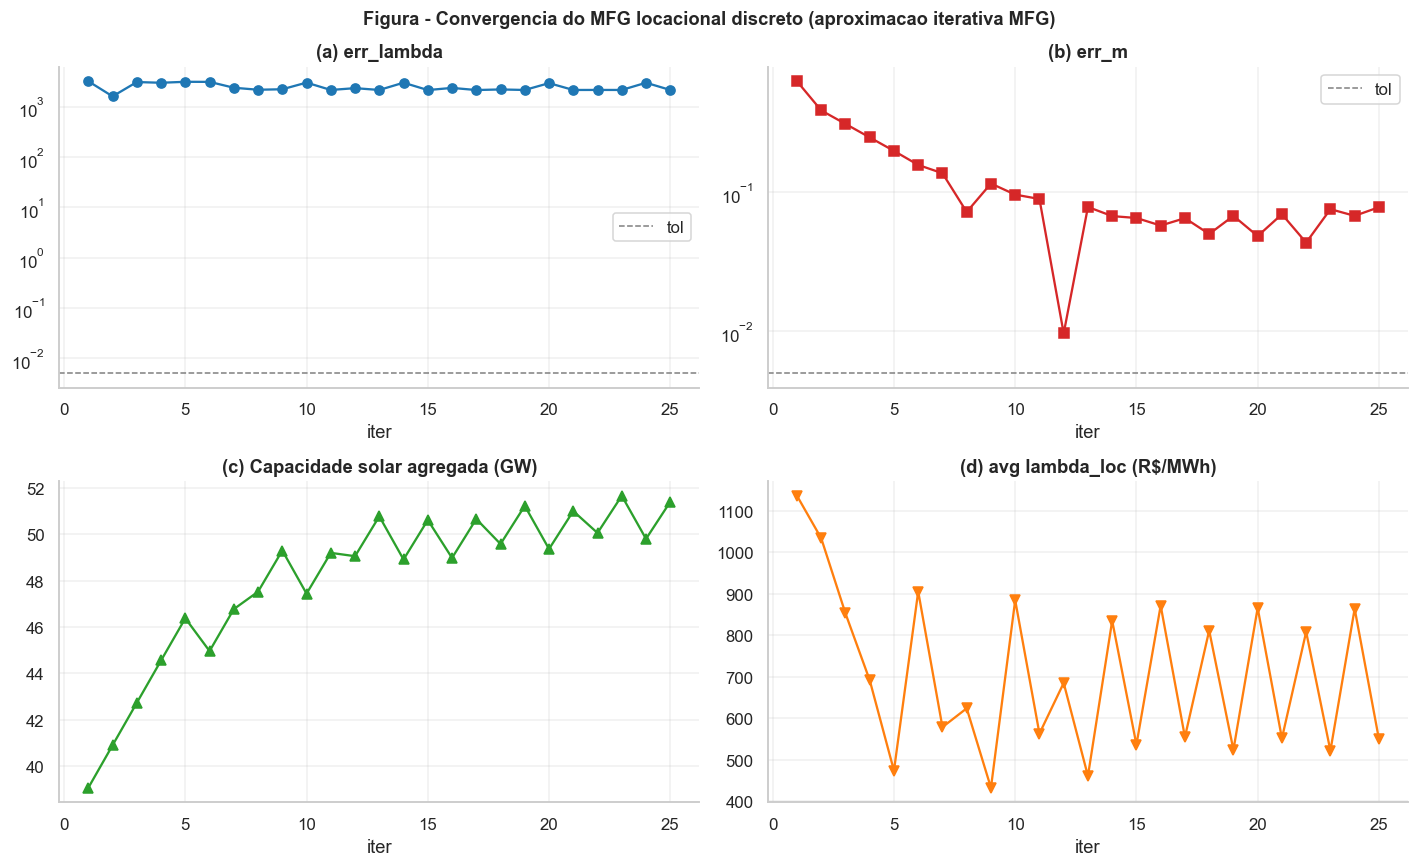

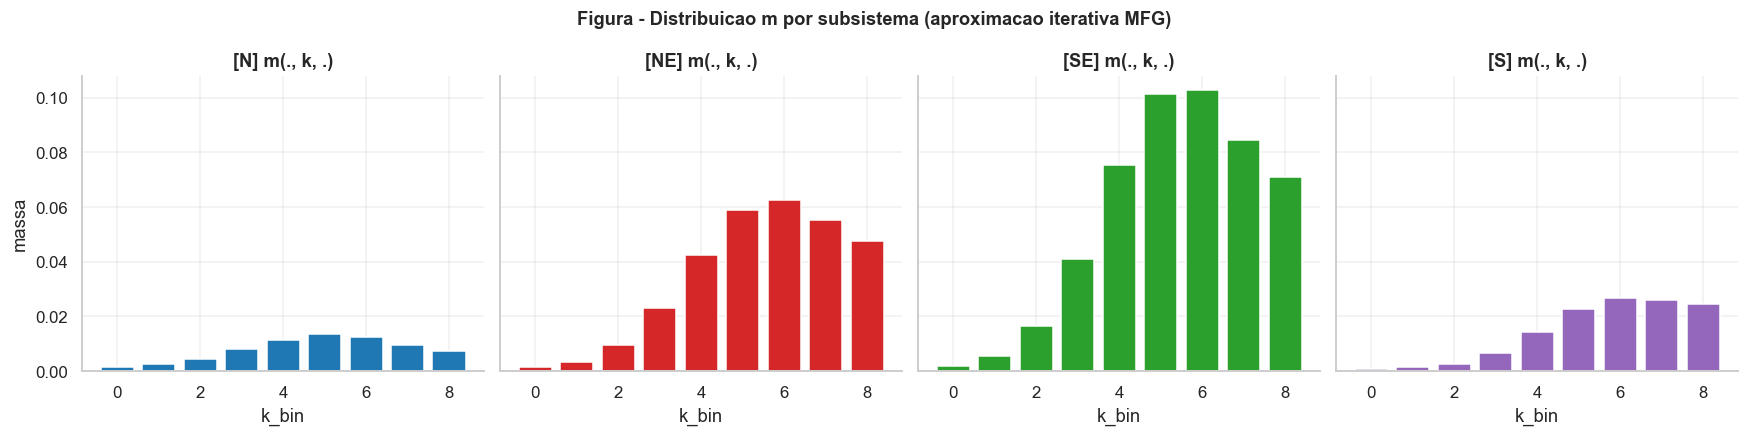

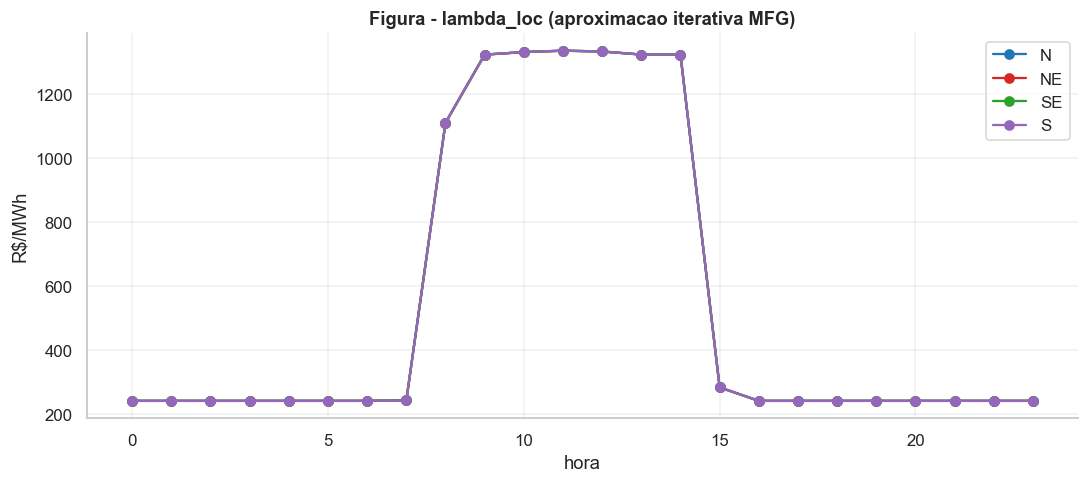

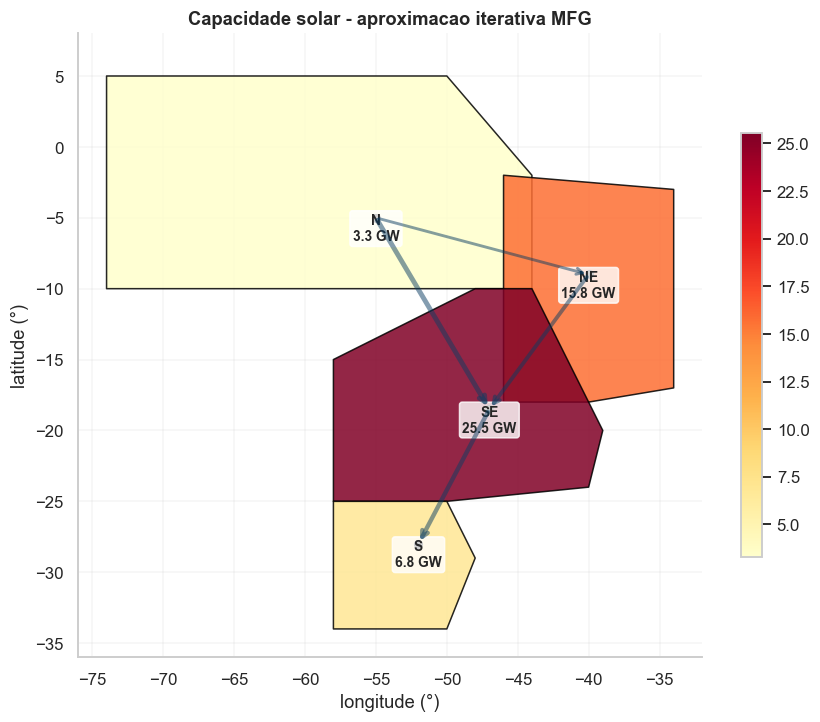

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(mfg_history["iteration"], mfg_history["err_lambda"], "o-", color="#1f77b4")
axes[0, 0].axhline(TOL, color="gray", ls="--", lw=1, label="tol")
axes[0, 0].set_yscale("log"); axes[0, 0].set_title("(a) err_lambda"); axes[0, 0].set_xlabel("iter"); axes[0, 0].legend(); axes[0, 0].grid(alpha=.3)
axes[0, 1].plot(mfg_history["iteration"], mfg_history["err_m"], "s-", color="#d62728")
axes[0, 1].axhline(TOL, color="gray", ls="--", lw=1, label="tol")
axes[0, 1].set_yscale("log"); axes[0, 1].set_title("(b) err_m"); axes[0, 1].set_xlabel("iter"); axes[0, 1].legend(); axes[0, 1].grid(alpha=.3)
axes[1, 0].plot(mfg_history["iteration"], np.array(mfg_history["total_capacity_MW"])/1000, "^-", color="#2ca02c")
axes[1, 0].set_title("(c) Capacidade solar agregada (GW)"); axes[1, 0].set_xlabel("iter"); axes[1, 0].grid(alpha=.3)
axes[1, 1].plot(mfg_history["iteration"], mfg_history["avg_lambda"], "v-", color="#ff7f0e")
axes[1, 1].set_title("(d) avg lambda_loc (R$/MWh)"); axes[1, 1].set_xlabel("iter"); axes[1, 1].grid(alpha=.3)
fig.suptitle(f"Figura - Convergencia do MFG locacional discreto ({mfg_status_label})", fontsize=12, fontweight="bold")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_mfg_convergence.png", bbox_inches="tight"); plt.show()

fig, axes = plt.subplots(1, N_LOC, figsize=(16, 4), sharey=True)
for i, ell in enumerate(LOCS):
    ax = axes[i]
    M_k = m_mfg[i].sum(axis=1)
    ax.bar(K_BINS, M_k, color=SUB_COLOR[ell])
    ax.set_title(f"[{ell}] m(., k, .)"); ax.set_xlabel("k_bin"); ax.grid(alpha=.3)
axes[0].set_ylabel("massa")
fig.suptitle(f"Figura - Distribuicao m por subsistema ({mfg_status_label})", fontsize=12, fontweight="bold")
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_mfg_distribution_by_location.png", bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(10, 4.5))
for ell in LOCS:
    ax.plot(np.arange(HOURS), lam_mfg[ell], "o-", color=SUB_COLOR[ell], label=ell)
ax.set_title(f"Figura - lambda_loc ({mfg_status_label})")
ax.set_xlabel("hora"); ax.set_ylabel("R$/MWh"); ax.legend(); ax.grid(alpha=.3)
fig.tight_layout(); fig.savefig(FIG_DIR / "fig_mfg_prices_by_location.png", bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(8, 7))
plot_subsystem_map(ax, {ell: K_by_subsys_mfg[ell]/1000 for ell in LOCS}, cmap_name="YlOrRd", title=f"Capacidade solar - {mfg_status_label}", label_fmt=".1f", label_unit=" GW")
for (o, d) in ALL_LINKS:
    la_o, lo_o = SUBSYS_CENTROIDS[o]; la_d, lo_d = SUBSYS_CENTROIDS[d]
    ax.annotate("", xy=(lo_d, la_d), xytext=(lo_o, la_o), arrowprops=dict(arrowstyle="->", color="#0a3d62", lw=max(1, F_MAX[(o, d)]/3000), alpha=0.5))
fig.tight_layout(); fig.savefig(FIG_DIR / "map_mfg_capacity_by_subsystem.png", bbox_inches="tight"); plt.show()


## 19. Investimento: alocação com orçamento fixo × livre entrada

Diferenciamos duas modalidades:

1. **`allocation_fixed_budget`**: capacidade total `K_TOT` é fixa; resolvemos a
   alocação `K_alloc[ell]` que minimiza o custo social agregado.
2. **`allocation_free_entry`**: para cada `K` na grade, calculamos margem
   privada por MW. Se margem ≥ 0, entra; senão, não entra. **Não** chamamos de
   equilíbrio se a margem permanece positiva no topo da grade (ampliar grid).


Alocação fixed-budget:
  K_N =   8.95 GW (obs   2.30 GW)
  K_NE =   9.98 GW (obs  11.40 GW)
  K_SE =  10.42 GW (obs  17.97 GW)
  K_S =   7.86 GW (obs   5.54 GW)



Varredura free-entry:
 K_total_MW  K_total_GW     cost_op    inv_anual     rev_anual  margem_anual  total_social entry_decision
    11164.0        11.0 932911717.0 5.045839e+09  8.989412e+10  8.484828e+10  5.978750e+09             in
    18606.0        19.0 768726525.0 8.409731e+09  1.498162e+11  1.414065e+11  9.178458e+09             in
    26049.0        26.0 604545637.0 1.177362e+10  2.097395e+11  1.979658e+11  1.237817e+10             in
    37213.0        37.0 374853655.0 1.681946e+10  2.701929e+11  2.533735e+11  1.719432e+10             in
    48376.0        48.0 178811548.0 2.186530e+10  2.513215e+11  2.294562e+11  2.204411e+10             in
    59540.0        60.0 124920866.0 2.691114e+10  3.284325e+10  5.932109e+09  2.703606e+10             in
    74425.0        74.0 105372369.0 3.363893e+10  2.798074e+10 -5.658185e+09  3.374430e+10            out
    93031.0        93.0  93332514.0 4.204866e+10  1.821570e+10 -2.383296e+10  4.214199e+10            out
   111638.0       112.0

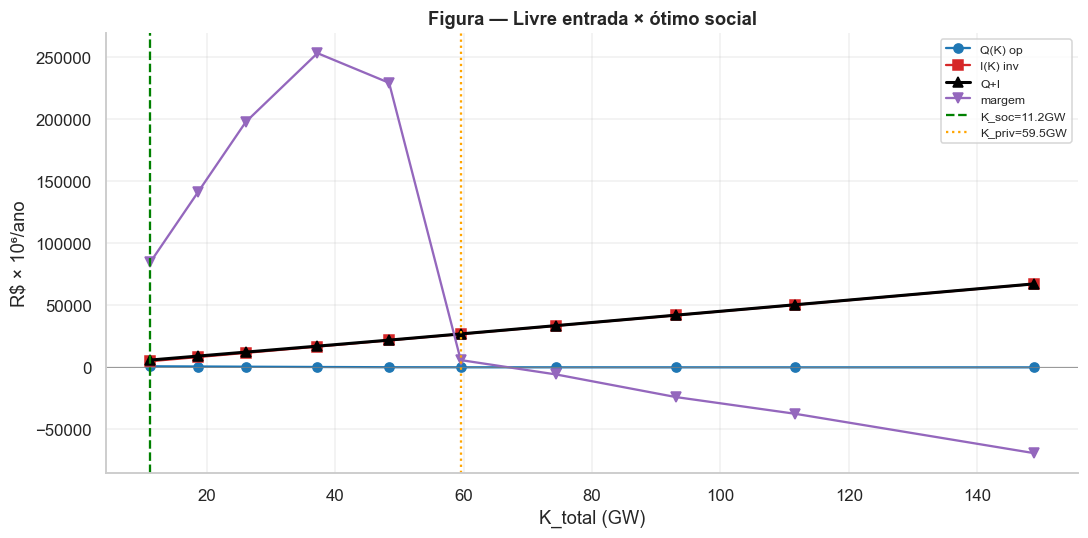

In [29]:
K_TOT = float(K_eff.loc[:, "K_s_eff_p99"].sum())

def allocation_fixed_budget(K_total: float, n_iter: int = 10, eta: float = 0.3) -> dict:
    """Alocação K_alloc[ell] que minimiza custo via best-response amortizado."""
    K_obs = {s: float(K_eff.loc[s, "K_s_eff_p99"]) for s in SUBSYS_ORDER}
    scale = K_total / sum(K_obs.values())
    K = {s: K_obs[s] * scale for s in SUBSYS_ORDER}
    hist = []
    for it in range(n_iter):
        G_s_alloc = {s: K[s] * a_s_loc[s] for s in SUBSYS_ORDER}
        r = clearing_locacional(G_s_alloc,
                                water_opportunity_cost=PARAMS["water_opportunity_cost"])
        rev = {}
        for s in SUBSYS_ORDER:
            rev[s] = float((r["lambda_loc"][s] * a_s_loc[s]).sum()) * 365.0
        marg = {s: rev[s] - q_reg[s] for s in SUBSYS_ORDER}
        pos = {s: max(marg[s], 0.0) for s in SUBSYS_ORDER}
        if sum(pos.values()) > 0:
            w = {s: pos[s] / sum(pos.values()) for s in SUBSYS_ORDER}
        else:
            w = {s: rev[s] / max(sum(rev.values()), 1e-9) for s in SUBSYS_ORDER}
        K_new = {s: (1 - eta) * K[s] + eta * w[s] * K_total for s in SUBSYS_ORDER}
        hist.append({"iter": it, **{f"K_{s}": K_new[s] for s in SUBSYS_ORDER},
                     **{f"marg_{s}": marg[s] for s in SUBSYS_ORDER}})
        K = K_new
    return {"K_alloc": K, "history": hist}


fixed_res = allocation_fixed_budget(K_TOT)
K_eq = fixed_res["K_alloc"]
print("Alocação fixed-budget:")
for s in SUBSYS_ORDER:
    print(f"  K_{s} = {K_eq[s]/1000:>6.2f} GW (obs {K_eff.loc[s,'K_s_eff_p99']/1000:>6.2f} GW)")


def allocation_free_entry(K_grid_MW: np.ndarray) -> pd.DataFrame:
    """Varre K_total e diagnostica entrada livre."""
    rows = []
    for K in K_grid_MW:
        K_alloc = {s: K * (K_eff.loc[s, "K_s_eff_p99"] / K_TOT) for s in SUBSYS_ORDER}
        G_s_alloc = {s: K_alloc[s] * a_s_loc[s] for s in SUBSYS_ORDER}
        r = clearing_locacional(G_s_alloc,
                                water_opportunity_cost=PARAMS["water_opportunity_cost"])
        rev_anual = 0.0
        inv_anual = 0.0
        for s in SUBSYS_ORDER:
            rev_anual += float((r["lambda_loc"][s] * a_s_loc[s] * K_alloc[s]).sum()) * 365.0
            inv_anual += q_reg[s] * K_alloc[s]
        rows.append({
            "K_total_MW": K,
            "K_total_GW": K/1000,
            "cost_op": r["cost"],
            "inv_anual": inv_anual,
            "rev_anual": rev_anual,
            "margem_anual": rev_anual - inv_anual,
            "total_social": r["cost"] + inv_anual,
            "entry_decision": "in" if (rev_anual - inv_anual) >= 0 else "out",
        })
    return pd.DataFrame(rows)


K_grid_MW = K_TOT * np.array([0.3, 0.5, 0.7, 1.0, 1.3, 1.6, 2.0, 2.5, 3.0, 4.0])
free_res = allocation_free_entry(K_grid_MW)
free_res.to_csv(TABLE_DIR / "tab_investimento_K_grid.csv", index=False, float_format="%.4f")
print("\nVarredura free-entry:")
print(free_res.round(0).to_string(index=False))

K_soc = float(free_res.loc[free_res["total_social"].idxmin(), "K_total_GW"])

mask_in = free_res["entry_decision"] == "in"
mask_out = free_res["entry_decision"] == "out"
if mask_in.all():
    K_priv = None
    diag_msg = (f"AVISO: margem >= 0 em TODA a grade (K_max = {free_res['K_total_GW'].max():.1f} GW). "
                "Não foi encontrado cruzamento na grade; ampliar grid ou regularizar o modelo.")
elif mask_out.all():
    K_priv = 0.0
    diag_msg = "Margem < 0 em TODA a grade => livre entrada implica K_priv = 0."
else:
    K_priv = float(free_res.loc[mask_in, "K_total_GW"].max())
    diag_msg = f"K_priv (maior K com margem >= 0) = {K_priv:.1f} GW."
print(f"\nK_soc = {K_soc:.1f} GW")
print(diag_msg)

# Tabela final: private vs social
priv_vs_soc = pd.DataFrame({
    "regime": ["allocation_fixed_budget", "allocation_free_entry", "social_optimum", "observed"],
    "K_total_GW": [K_TOT/1000, (K_priv if K_priv is not None else np.nan),
                   K_soc, K_S_OBS_TOTAL/1000],
    "comment": ["K fixo em K_TOT, distribuído por margem",
                diag_msg, "argmin Q+I na grade",
                "p99 da geração observada"],
})
priv_vs_soc.to_csv(TABLE_DIR / "tab_private_vs_social_capacity.csv",
                   index=False, float_format="%.3f")
print("\n", priv_vs_soc.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(free_res["K_total_GW"], free_res["cost_op"]/1e6,    "o-", color="#1f77b4", label="Q(K) op")
ax.plot(free_res["K_total_GW"], free_res["inv_anual"]/1e6,  "s-", color="#d62728", label="I(K) inv")
ax.plot(free_res["K_total_GW"], free_res["total_social"]/1e6,"^-", color="black", lw=2, label="Q+I")
ax.plot(free_res["K_total_GW"], free_res["margem_anual"]/1e6,"v-", color="#9467bd", label="margem")
ax.axhline(0, color="gray", ls="-", lw=.5)
ax.axvline(K_soc, color="green", ls="--", label=f"K_soc={K_soc:.1f}GW")
if K_priv is not None and K_priv > 0:
    ax.axvline(K_priv, color="orange", ls=":", label=f"K_priv={K_priv:.1f}GW")
ax.set_xlabel("K_total (GW)"); ax.set_ylabel("R$ × 10⁶/ano")
ax.set_title("Figura — Livre entrada × ótimo social")
ax.legend(fontsize=8); ax.grid(alpha=.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_private_vs_social_capacity.png", bbox_inches="tight")
plt.show()


## 20. Mapas estáticos por subsistema

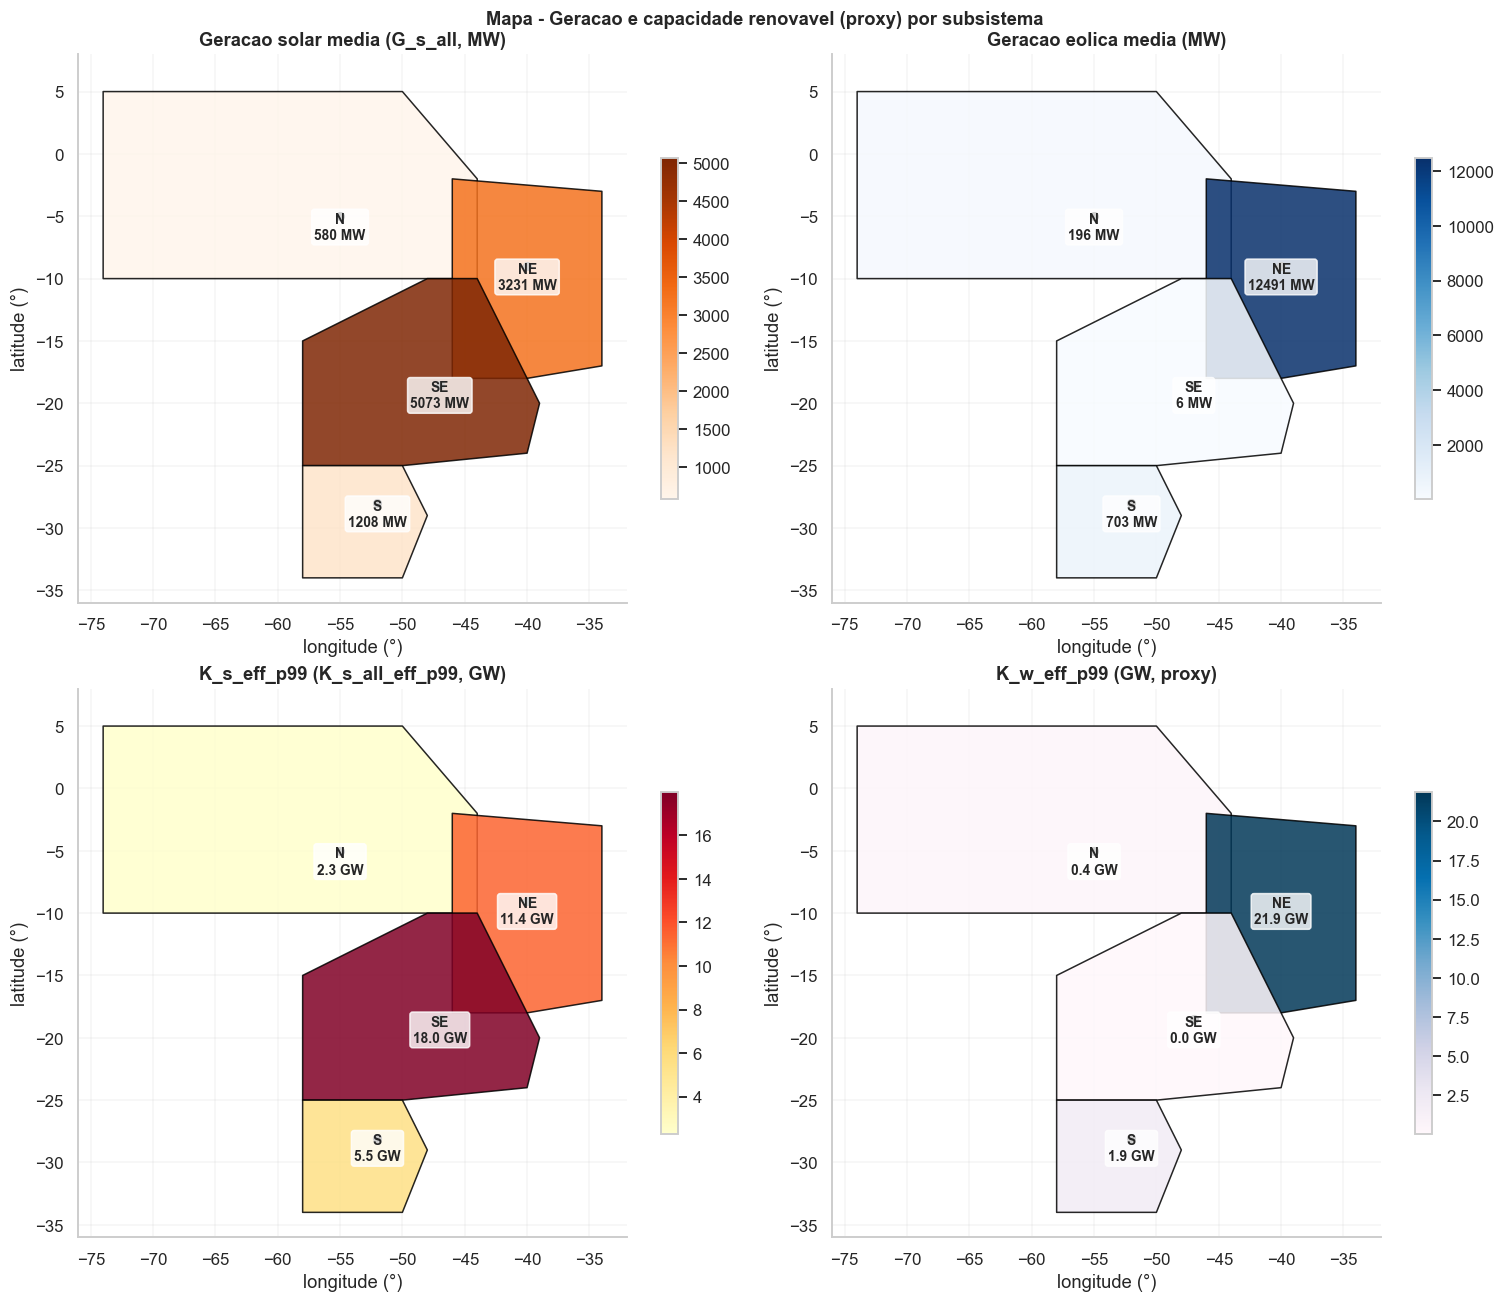

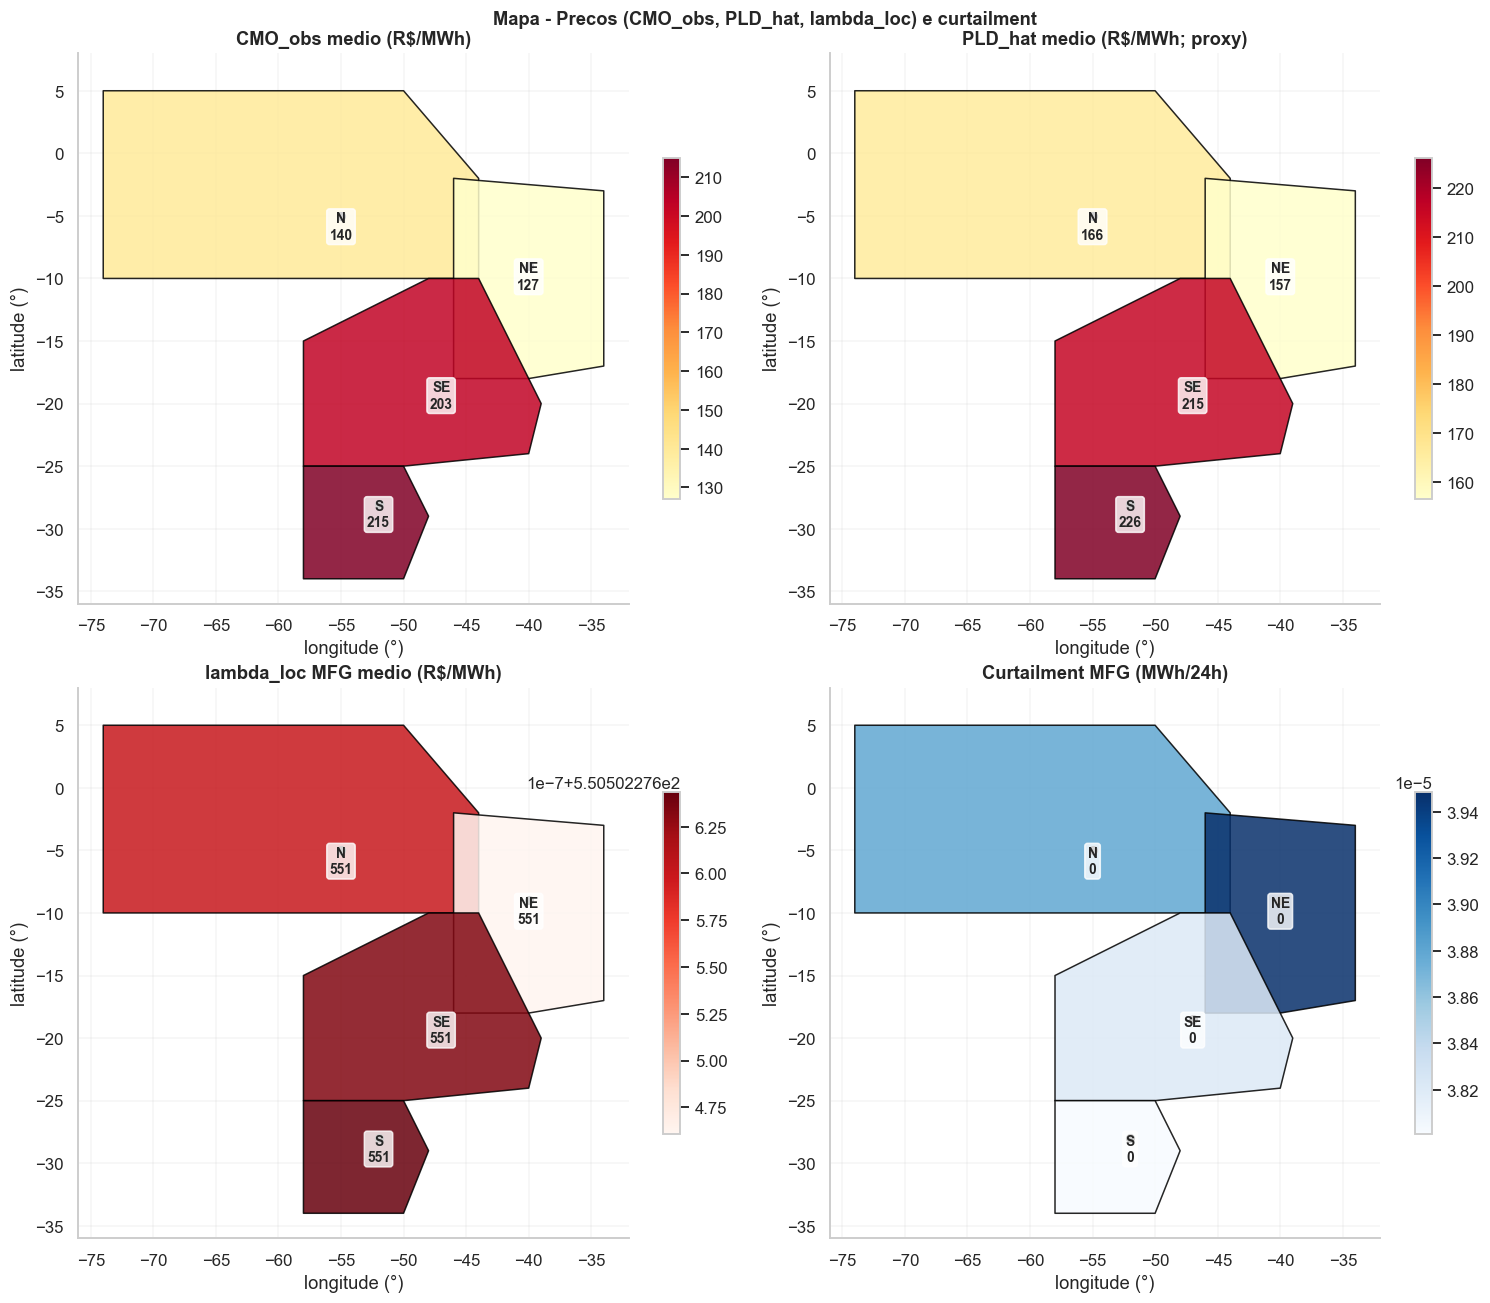

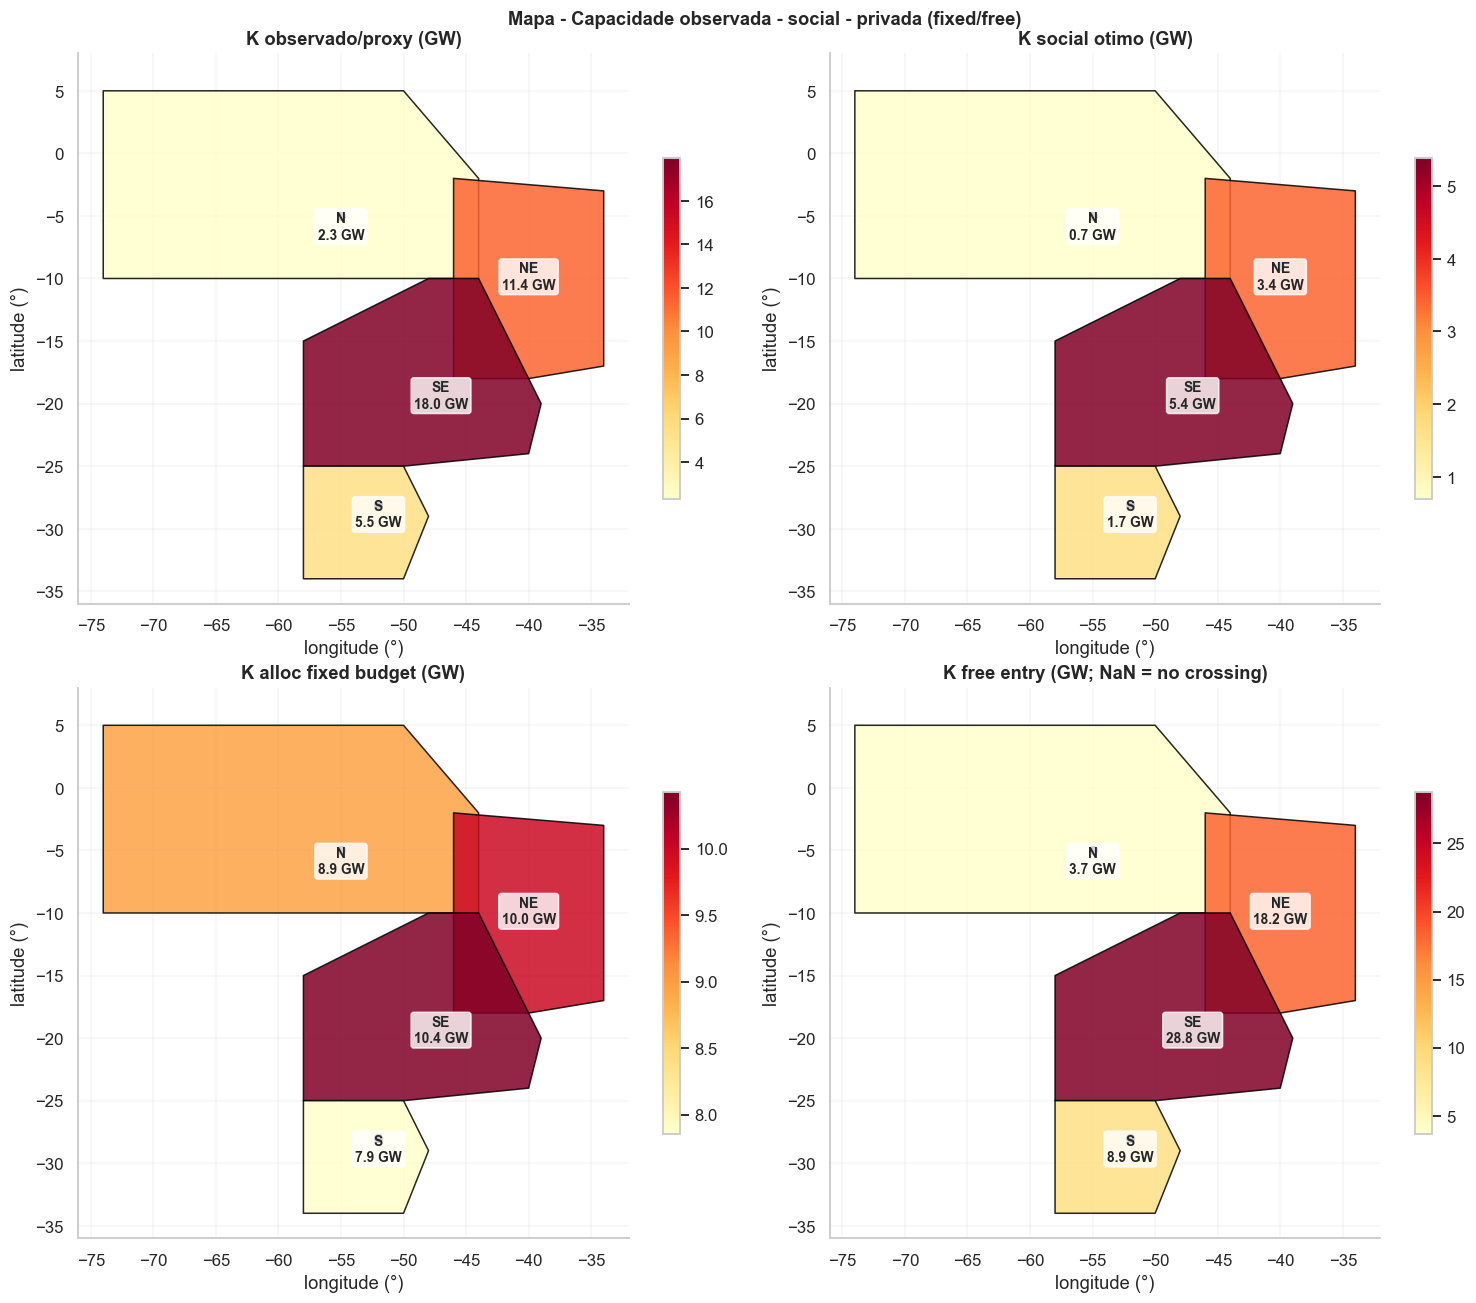

Soma K_soc_GW = 11.164 GW | K_soc = 11.164 GW


In [30]:
# Mapa 1: solar/wind generation e K_eff_p99 por subsistema
gs_mean = panel.groupby("id_subsistema")[DEFAULT_SOLAR_COL].mean().to_dict()
gw_mean = panel.groupby("id_subsistema")["G_w_total"].mean().to_dict()
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
plot_subsystem_map(axes[0, 0], gs_mean, cmap_name="Oranges", title=f"Geracao solar media ({DEFAULT_SOLAR_COL}, MW)", label_fmt=".0f", label_unit=" MW")
plot_subsystem_map(axes[0, 1], gw_mean, cmap_name="Blues", title="Geracao eolica media (MW)", label_fmt=".0f", label_unit=" MW")
plot_subsystem_map(axes[1, 0], {s: K_eff.loc[s, "K_s_eff_p99"]/1000 for s in SUBSYS_ORDER}, cmap_name="YlOrRd", title=f"K_s_eff_p99 ({K_SOLAR_DEFAULT}, GW)", label_fmt=".1f", label_unit=" GW")
plot_subsystem_map(axes[1, 1], {s: K_eff.loc[s, "K_w_eff_p99"]/1000 for s in SUBSYS_ORDER}, cmap_name="PuBu", title="K_w_eff_p99 (GW, proxy)", label_fmt=".1f", label_unit=" GW")
fig.suptitle("Mapa - Geracao e capacidade renovavel (proxy) por subsistema", fontsize=12, fontweight="bold")
fig.tight_layout(); fig.savefig(FIG_DIR / "map_solar_wind_by_region.png", bbox_inches="tight"); plt.show()

# Mapa 2: preco medio e curtailment
cmo_mean = panel.groupby("id_subsistema")["CMO_obs"].mean().to_dict()
pld_hat_mean = panel.groupby("id_subsistema")["PLD_hat"].mean().to_dict()
lam_mfg_mean = {ell: float(lam_mfg[ell].mean()) for ell in LOCS}
curt_mfg_by = {ell: float(res_mfg["curt"][ell].sum()) for ell in LOCS}
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
plot_subsystem_map(axes[0, 0], cmo_mean, cmap_name="YlOrRd", title="CMO_obs medio (R$/MWh)", label_fmt=".0f")
plot_subsystem_map(axes[0, 1], pld_hat_mean, cmap_name="YlOrRd", title="PLD_hat medio (R$/MWh; proxy)", label_fmt=".0f")
plot_subsystem_map(axes[1, 0], lam_mfg_mean, cmap_name="Reds", title="lambda_loc MFG medio (R$/MWh)", label_fmt=".0f")
plot_subsystem_map(axes[1, 1], curt_mfg_by, cmap_name="Blues", title="Curtailment MFG (MWh/24h)", label_fmt=".0f")
fig.suptitle("Mapa - Precos (CMO_obs, PLD_hat, lambda_loc) e curtailment", fontsize=12, fontweight="bold")
fig.tight_layout(); fig.savefig(FIG_DIR / "map_prices_curtailment_by_subsystem.png", bbox_inches="tight"); plt.show()

# Mapa 3: private vs social
K_obs_GW = {s: K_eff.loc[s, "K_s_eff_p99"]/1000 for s in SUBSYS_ORDER}
K_fixed_GW = {s: K_eq[s]/1000 for s in SUBSYS_ORDER}
K_soc_GW = {s: K_soc * K_eff.loc[s, "K_s_eff_p99"] / K_TOT for s in SUBSYS_ORDER}
if K_priv is not None and K_priv > 0:
    K_priv_GW = {s: K_priv * K_eff.loc[s, "K_s_eff_p99"] / K_TOT for s in SUBSYS_ORDER}
else:
    K_priv_GW = {s: np.nan for s in SUBSYS_ORDER}
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
plot_subsystem_map(axes[0, 0], K_obs_GW, cmap_name="YlOrRd", title="K observado/proxy (GW)", label_fmt=".1f", label_unit=" GW")
plot_subsystem_map(axes[0, 1], K_soc_GW, cmap_name="YlOrRd", title="K social otimo (GW)", label_fmt=".1f", label_unit=" GW")
plot_subsystem_map(axes[1, 0], K_fixed_GW, cmap_name="YlOrRd", title="K alloc fixed budget (GW)", label_fmt=".1f", label_unit=" GW")
plot_subsystem_map(axes[1, 1], K_priv_GW, cmap_name="YlOrRd", title="K free entry (GW; NaN = no crossing)", label_fmt=".1f", label_unit=" GW")
fig.suptitle("Mapa - Capacidade observada - social - privada (fixed/free)", fontsize=12, fontweight="bold")
fig.tight_layout(); fig.savefig(FIG_DIR / "map_private_vs_social_capacity.png", bbox_inches="tight"); plt.show()
print("Soma K_soc_GW =", round(sum(K_soc_GW.values()), 3), "GW | K_soc =", round(K_soc, 3), "GW")


## 21. Apêndice B — métricas consolidadas

In [31]:
metrics = panel.groupby("id_subsistema").agg(
    CMO_obs_avg=("CMO_obs", "mean"),
    CMO_obs_p95=("CMO_obs", lambda x: float(np.nanpercentile(x.dropna(), 95))),
    PLD_hat_avg=("PLD_hat", "mean"),
    L_global_mean=("L_global", "mean"), L_global_max=("L_global", "max"),
    L_net_default_mean=(L_NET_DEFAULT, "mean"), L_res_default_mean=(L_RES_DEFAULT, "mean"),
    G_s_centralizada=("G_s_centralizada", "sum"), G_s_MMGD=("G_s_MMGD", "sum"), G_s_all=("G_s_all", "sum"),
    G_w_total=("G_w_total", "sum"), G_h_total=("G_h_total", "sum"),
    Ramp_res_max_pos=("dL_res", "max"), Ramp_res_max_neg=("dL_res", "min"),
    Ramp_net_max_pos=("dL_net_s", "max"), Ramp_net_max_neg=("dL_net_s", "min"),
).reindex(SUBSYS_ORDER)
fc_cmo = fcap.query("tag == 'F_capture_CMO'").pivot_table(index="id_subsistema", columns="fonte", values="F_capture").reindex(SUBSYS_ORDER)
metrics["F_capture_CMO_solar"] = fc_cmo["solar"]
metrics["F_capture_CMO_wind"] = fc_cmo["wind"]
metrics["K_mfg_solar_MW"] = pd.Series(K_by_subsys_mfg)
metrics["lambda_mfg_mean"] = pd.Series(lam_mfg_mean)
metrics.round(2).to_csv(TABLE_DIR / "tab_apendice_B_metricas.csv")
print(metrics.round(2).to_string())


               CMO_obs_avg  CMO_obs_p95  PLD_hat_avg  L_global_mean  L_global_max  L_net_default_mean  L_res_default_mean  G_s_centralizada     G_s_MMGD      G_s_all    G_w_total     G_h_total  Ramp_res_max_pos  Ramp_res_max_neg  Ramp_net_max_pos  Ramp_net_max_neg  F_capture_CMO_solar  F_capture_CMO_wind  K_mfg_solar_MW  lambda_mfg_mean
id_subsistema                                                                                                                                                                                                                                                                                                                                     
N                   139.84       340.35       166.19        8788.56      12204.28             8211.75             8019.24           8742.14   4220830.55   4229572.69   1431912.89  5.930865e+07            673.09          -1338.20            721.02          -1321.26                 0.67                1.36         3261.05 